In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import pickle
import os

years = [2019, 2020, 2021, 2022, 2023, 2024]

modes = {}
graphs = {}

base_modes = "../../data/03_modes"

# List all year_month folders
year_months = sorted([
    d for d in os.listdir(base_modes)
    if "_" in d and os.path.isdir(os.path.join(base_modes, d))
])

for ym in year_months:
    year, month = ym.split("_")
    for speed in ["fast", "medium", "slow"]:
        file_path = f"../../data/04_graphs/{ym}/{speed}_graph.gpickle"
        with open(file_path, "rb") as f:
            graphs[f"graph_{speed}_{ym}"] = pickle.load(f)
                
        modes[f"{speed}_{ym}"] = pd.read_parquet(f"../../data/03_modes/{ym}/{speed}_emd.parquet")

In [10]:
data = []

for name, G in graphs.items():
    _, speed, year, month = name.split("_")
    ym = str(year) + "_" + str(month)

    # Métricas básicas
    degrees = dict(G.degree(weight="weight"))
    wc = nx.clustering(G, weight="weight")

    assort = nx.degree_assortativity_coefficient(G)

    # --- Resistance distance completa ---
    R = dict(nx.resistance_distance(G, weight="weight"))
    nodes = list(G.nodes())

    # Métrica nodal correta
    nodal_resistance = {
        i: np.mean([R[i][j] for j in nodes if j != i])
        for i in nodes
    }

    for node in G.nodes():
        data.append({
            "node": node,
            "degree": degrees[node],
            "nodal_resistance": nodal_resistance[node],
            "speed": speed.capitalize(),
            "year_month": ym,
            "weighted_clustering": wc[node],
            "assortativity": assort
        })

df = pd.DataFrame(data)

In [6]:
from tqdm import tqdm

new_metrics = []

for name, G in tqdm(graphs.items(), desc="Computing nodal centralities"):
    _, speed, year, month = name.split("_")
    ym = f"{year}_{month}"

    # --- Novas métricas ---
    betw = nx.betweenness_centrality(
        G,
        weight="weight",
        normalized=True
    )

    eig = nx.eigenvector_centrality(
        G,
        weight="weight",
        max_iter=1000
    )

    close = nx.closeness_centrality(
        G,
        distance="weight"
    )

    core = nx.core_number(G)

    for node in G.nodes():
        new_metrics.append({
            "node": node,
            "speed": speed.capitalize(),
            "year_month": ym,
            "betweenness": betw[node],
            "eigenvector": eig[node],
            "closeness": close[node],
            "k_core": core[node]
        })

df_new_metrics = pd.DataFrame(new_metrics)

Computing nodal centralities: 100%|██████████| 216/216 [45:41<00:00, 12.69s/it]


In [15]:
df.merge(df_new_metrics, on=["node", "speed", "year_month"], how="left").to_parquet("../../data/05_metrics/graph_metrics_df.parquet")

In [13]:
df["year_month_dt"] = pd.to_datetime(df["year_month"], format="%Y_%m")

## Reading data

In [2]:
df = pd.read_parquet("../../data/05_metrics/graph_metrics_df.parquet")

In [18]:
# df_sector = pd.read_parquet("../../data/01_raw/screener_result.parquet")[["Ticker", "Sector", "Market Cap"]]
# df = df.merge(df_sector, how="left", left_on="node", right_on="Ticker").drop(columns="Ticker")

In [3]:
df

,node,degree,nodal_resistance,speed,year_month,weighted_clustering,assortativity,year_month_dt,Sector,Market Cap,betweenness,eigenvector,closeness,k_core
0,AACG,1.253326,0.210281,Fast,2019_01,0.194223,-0.193668,2019-01-01,Consumer Defensive,2.840000e+07,0.000000,0.005541,0.746865,3
1,AAOI,0.990528,0.168345,Fast,2019_01,0.167263,-0.193668,2019-01-01,Technology,1.970000e+09,0.000635,0.002299,0.799886,3
2,AAPL,1.067716,0.217574,Fast,2019_01,0.212594,-0.193668,2019-01-01,Technology,4.047240e+12,0.000004,0.002171,0.711578,3
3,ABTC,0.078109,0.189065,Fast,2019_01,0.070319,-0.193668,2019-01-01,Financial,1.490000e+09,0.018969,0.000134,0.792821,3
4,ABVC,0.930118,0.195045,Fast,2019_01,0.236775,-0.193668,2019-01-01,Healthcare,5.079000e+07,0.002873,0.018058,0.990552,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
201691,ZTEK,1.132227,0.376514,Slow,2024_12,0.489847,-0.180859,2024-12-01,Healthcare,7.093000e+07,0.000000,0.000026,0.371272,3
201692,ZTWO,0.277966,0.207279,Slow,2024_12,0.194270,-0.180859,2024-12-01,Financial,NaN,0.336741,0.002709,0.792626,3
201693,ZUMZ,3.694339,0.302110,Slow,2024_12,0.383927,-0.180859,2024-12-01,Consumer Cyclical,4.924600e+08,0.000006,0.018479,0.436663,3
201694,ZVRA,1.303168,0.257017,Slow,2024_12,0.174067,-0.180859,2024-12-01,Healthcare,4.593900e+08,0.008084,0.000018,0.486407,3


## Análise 1 - Weighted degree

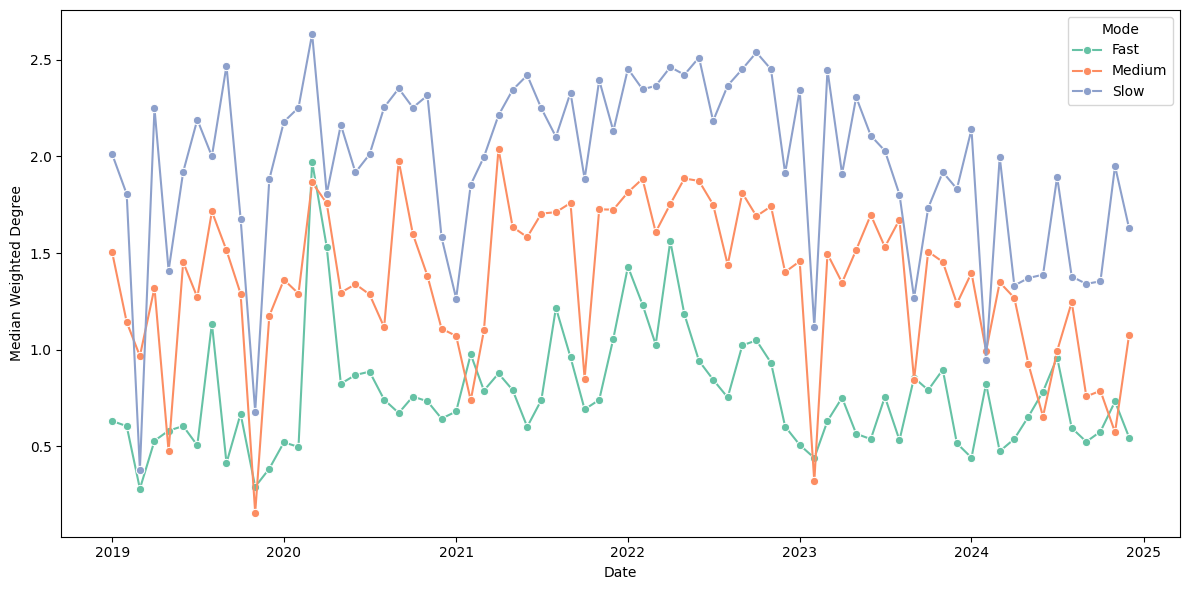

In [67]:
from matplotlib.lines import Line2D

plt.figure(figsize=(12,6))

df_med = (
    df.groupby(["year_month_dt", "speed"], as_index=False)
      .agg({"degree": "median"})
)

sns.lineplot(
    data=df_med,
    x="year_month_dt",
    y="degree",
    hue="speed",
    palette="Set2",
    marker="o"
)

plt.legend(title="Mode")
plt.xlabel("Date")
plt.ylabel("Median Weighted Degree")
plt.tight_layout()
plt.show()

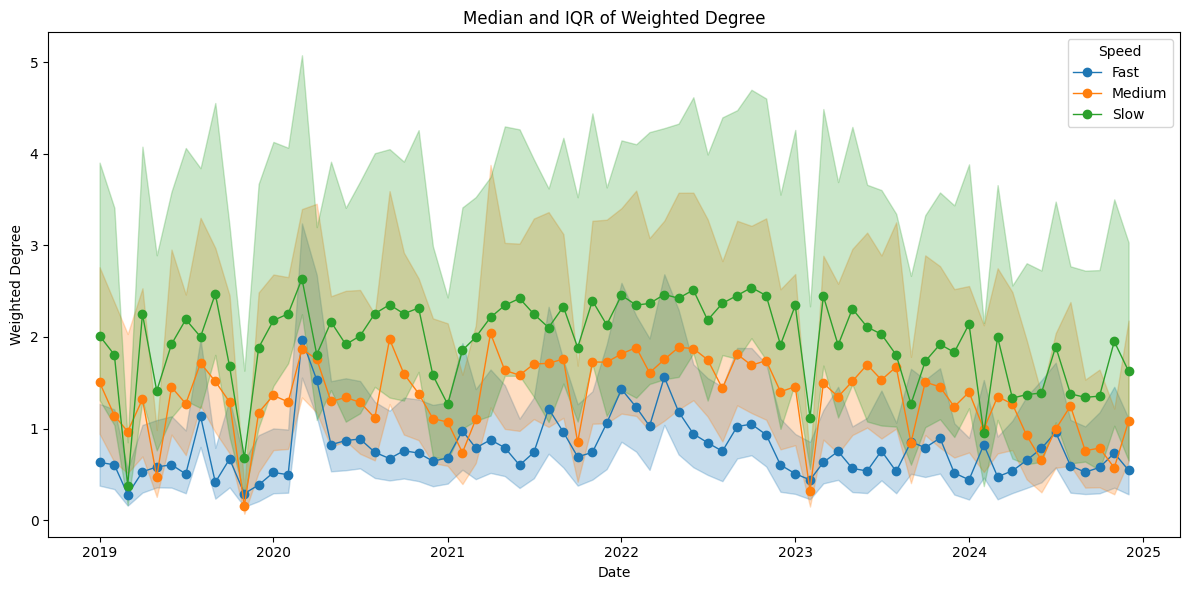

In [123]:
q = ( 
    df.groupby(["year_month_dt", "speed"])["degree"] 
    .quantile([0.25, 0.5, 0.75]) 
    .unstack() 
    .reset_index() 
    )
q.columns = ["year_month_dt", "speed", "q25", "q50", "q75"]

# speeds em ordem fixa (importante para consistência)
speeds = sorted(q["speed"].unique())

# extrair cores da paleta Set2
# paleta com mais contraste
palette = sns.color_palette("tab10", n_colors=len(speeds))
color_map = dict(zip(speeds, palette))

# mapear speed -> cor
color_map = dict(zip(speeds, palette))

plt.figure(figsize=(12,6))

for speed in speeds:
    d = q[q["speed"] == speed].sort_values("year_month_dt")
    c = color_map[speed]

    # banda Q25–Q75
    plt.fill_between(
        d["year_month_dt"],
        d["q25"],
        d["q75"],
        color=c,
        alpha=0.25
    )

    # mediana
    plt.plot(
        d["year_month_dt"],
        d["q50"],
        color=c,
        linewidth=1,
        marker="o",
        label=speed
    )

plt.xlabel("Date")
plt.ylabel("Weighted Degree")
plt.title("Median and IQR of Weighted Degree")
plt.legend(title="Speed")
plt.xticks()
plt.tight_layout()
plt.show()

Median Weighted Degree por modo: 

Slow > Medium > Fast de forma quase monotônica por todo o período. O slow mode tem grau mediano persistenteente mais alto, o que significa conexões fortes e duradouras no longo prazo. 

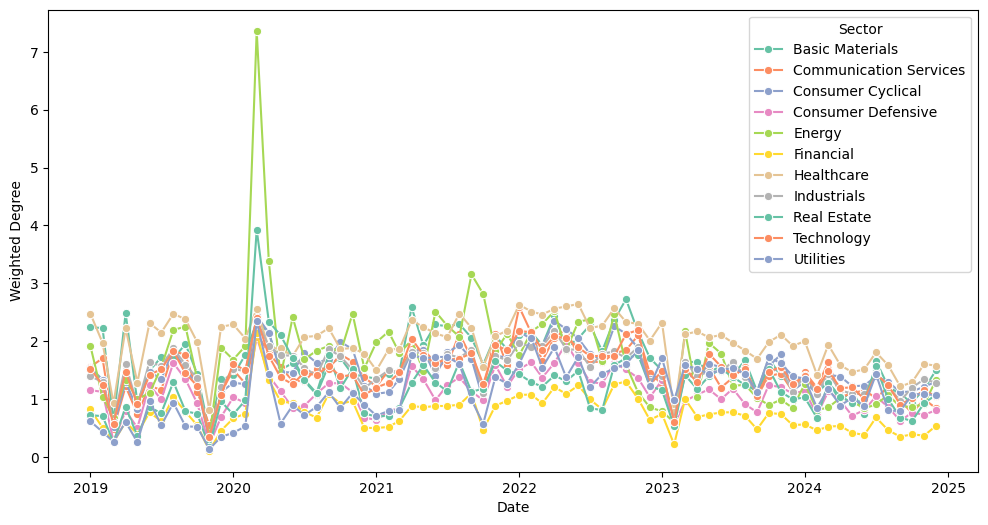

In [8]:
plt.figure(figsize=(12,6))

df_med = (
    df.groupby(["year_month_dt", "Sector"], as_index=False)
      .agg({"degree": "median"})
)

sns.lineplot(
    data=df_med,
    x="year_month_dt",
    y="degree",
    hue="Sector",
    palette="Set2",
    marker="o"
)

plt.xlabel("Date")
plt.ylabel("Weighted Degree")
plt.show()

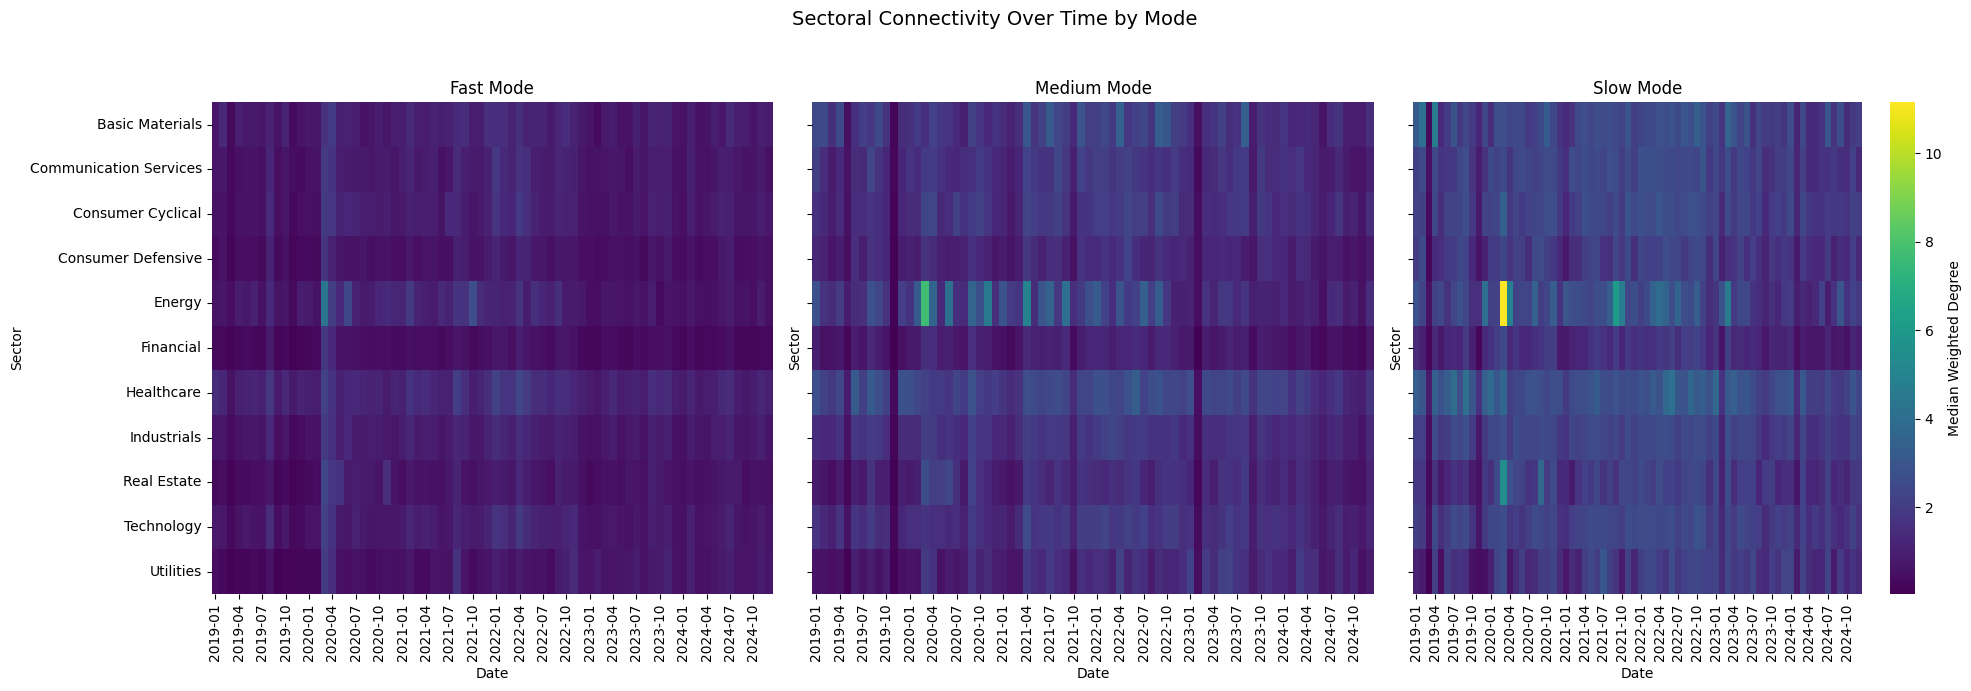

In [9]:
modes = ["Fast", "Medium", "Slow"]

# Calcular df_med por modo
df_med = (
    df.groupby(["year_month_dt", "Sector", "speed"], as_index=False)
      .agg({"degree": "median"})
)

# Criar pivots por modo
pivots = {
    mode: df_med[df_med["speed"] == mode].pivot(
        index="Sector",
        columns="year_month_dt",
        values="degree"
    )
    for mode in modes
}

# Escala comum de cores
vmin = min(p.min().min() for p in pivots.values())
vmax = max(p.max().max() for p in pivots.values())

fig, axes = plt.subplots(
    1, 3,
    figsize=(20, 7),
    sharey=True
)

for ax, mode in zip(axes, modes):
    sns.heatmap(
        pivots[mode],
        ax=ax,
        cmap="viridis",
        vmin=vmin,
        vmax=vmax,
        cbar=(mode == "Slow"),  # barra só no último
        cbar_kws={"label": "Median Weighted Degree"} if mode == "Slow" else None
    )

    # Format x-ticks
    xticks = ax.get_xticks()
    xticklabels = [
        pivots[mode].columns[int(tick)].strftime("%Y-%m")
        if int(tick) < len(pivots[mode].columns) else ""
        for tick in xticks
    ]
    ax.set_xticklabels(xticklabels, rotation=90)

    ax.set_title(f"{mode} Mode")
    ax.set_xlabel("Date")

axes[0].set_ylabel("Sector")

plt.suptitle("Sectoral Connectivity Over Time by Mode", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

Fast mode: intensidades baixcas, picos episódicos e localizados. Conectividade idiossincrática, propagação curta, pouco sistêmica.

Medium mode: Setores começam a se diferenciar mais, energy e healthcare ganham mais peso. 

Slow mode: estrutura clara, dominância de energy e healthcare, setores funcionam como backbones do sistema financeiro. 

C:\Users\groque\AppData\Local\Temp\ipykernel_9352\3861215459.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["year_month_dt", "mcap_bin", "speed"], as_index=False)


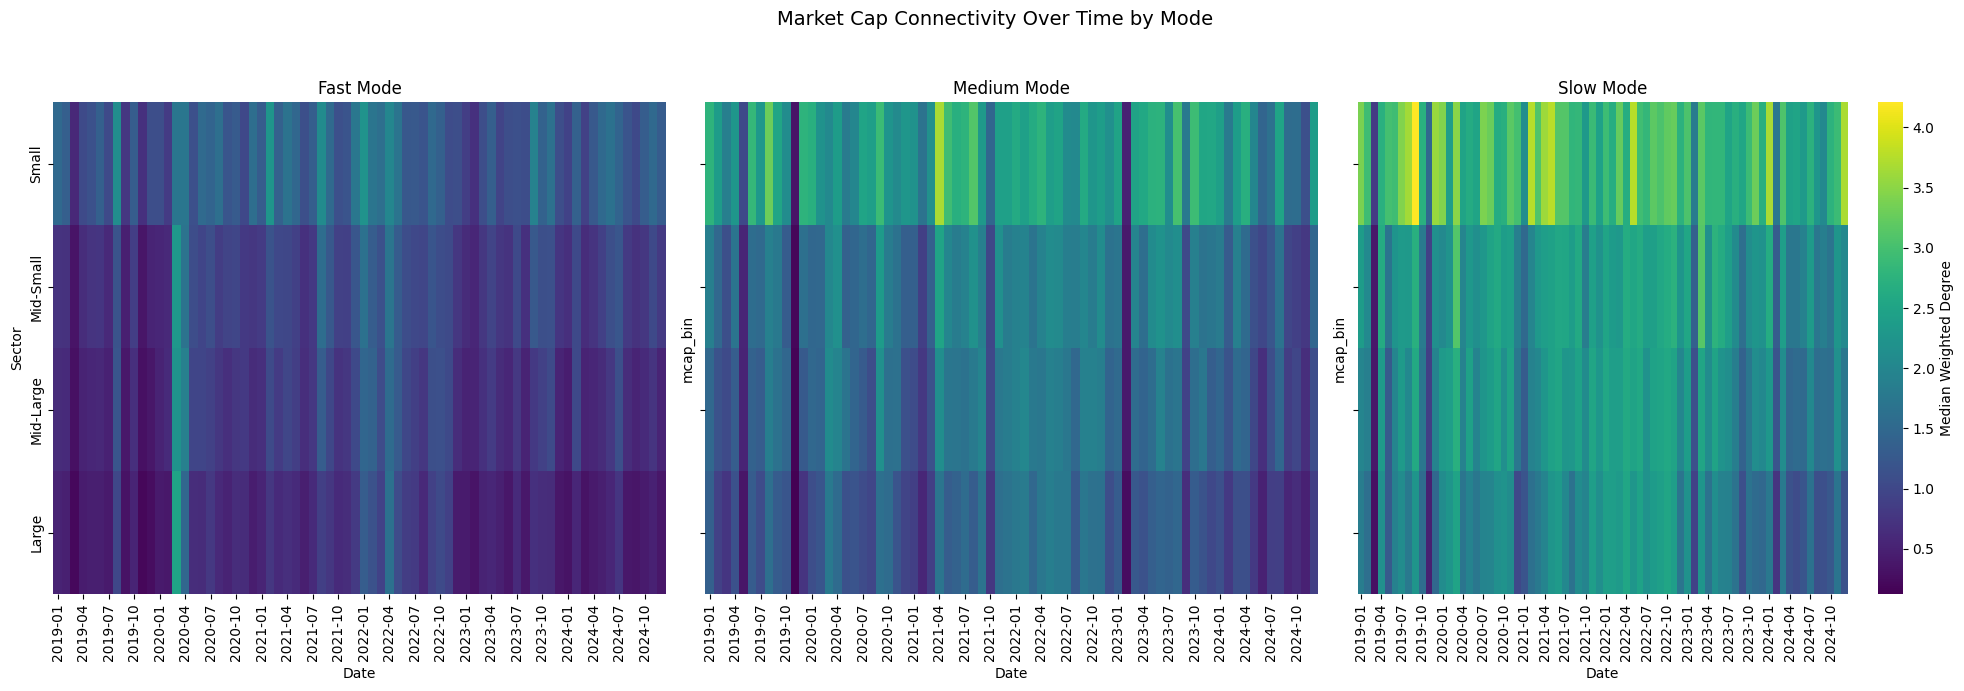

In [59]:
modes = ["Fast", "Medium", "Slow"]

# Calcular df_med por modo
df_med = (
    df.groupby(["year_month_dt", "mcap_bin", "speed"], as_index=False)
      .agg({"degree": "median"})
)

# Criar pivots por modo
pivots = {
    mode: df_med[df_med["speed"] == mode].pivot(
        index="mcap_bin",
        columns="year_month_dt",
        values="degree"
    )
    for mode in modes
}

# Escala comum de cores
vmin = min(p.min().min() for p in pivots.values())
vmax = max(p.max().max() for p in pivots.values())

fig, axes = plt.subplots(
    1, 3,
    figsize=(20, 7),
    sharey=True
)

for ax, mode in zip(axes, modes):
    sns.heatmap(
        pivots[mode],
        ax=ax,
        cmap="viridis",
        vmin=vmin,
        vmax=vmax,
        cbar=(mode == "Slow"),  # barra só no último
        cbar_kws={"label": "Median Weighted Degree"} if mode == "Slow" else None
    )

    # Format x-ticks
    xticks = ax.get_xticks()
    xticklabels = [
        pivots[mode].columns[int(tick)].strftime("%Y-%m")
        if int(tick) < len(pivots[mode].columns) else ""
        for tick in xticks
    ]
    ax.set_xticklabels(xticklabels, rotation=90)

    ax.set_title(f"{mode} Mode")
    ax.set_xlabel("Date")

axes[0].set_ylabel("Sector")

plt.suptitle("Market Cap Connectivity Over Time by Mode", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

Fast mode: Small Caps dominam, alta variabilidade, maior transmissão de risco.

Medium mode: Mid e Large começam a ganhar mais peso. 

Slow mode: Maior conectividade ainda concentrada em small caps, mas todos os caps apresentam boa conectividade, risco mais bem distribuído.

## Análise 2: Resistance distance

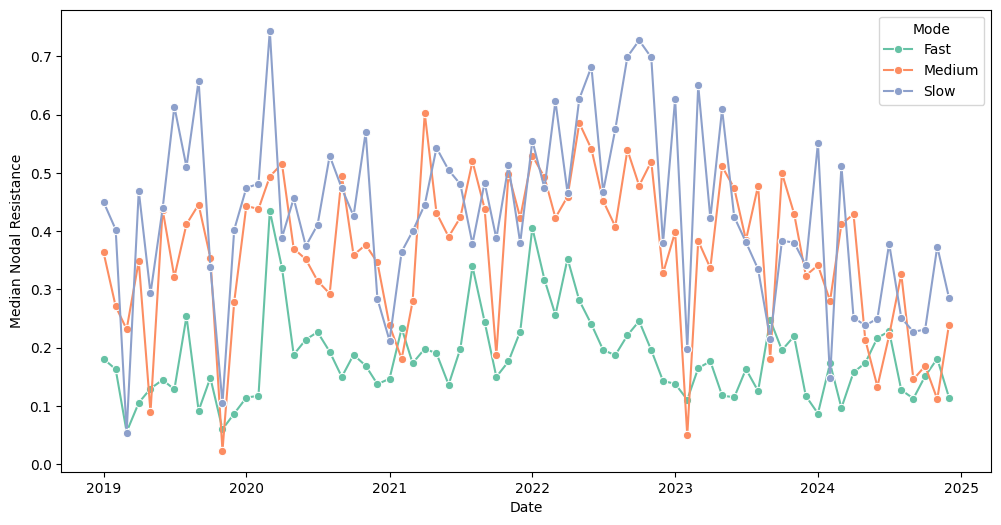

In [61]:
plt.figure(figsize=(12,6))

df_med = (
    df.groupby(["year_month_dt", "speed"], as_index=False)
      .agg({"nodal_resistance": "median"})
)

sns.lineplot(
    data=df_med,
    x="year_month_dt",
    y="nodal_resistance",
    hue="speed",
    palette="Set2",
    marker="o"
)

plt.legend(title="Mode")
plt.xlabel("Date")
plt.ylabel("Median Nodal Resistance")
plt.show()

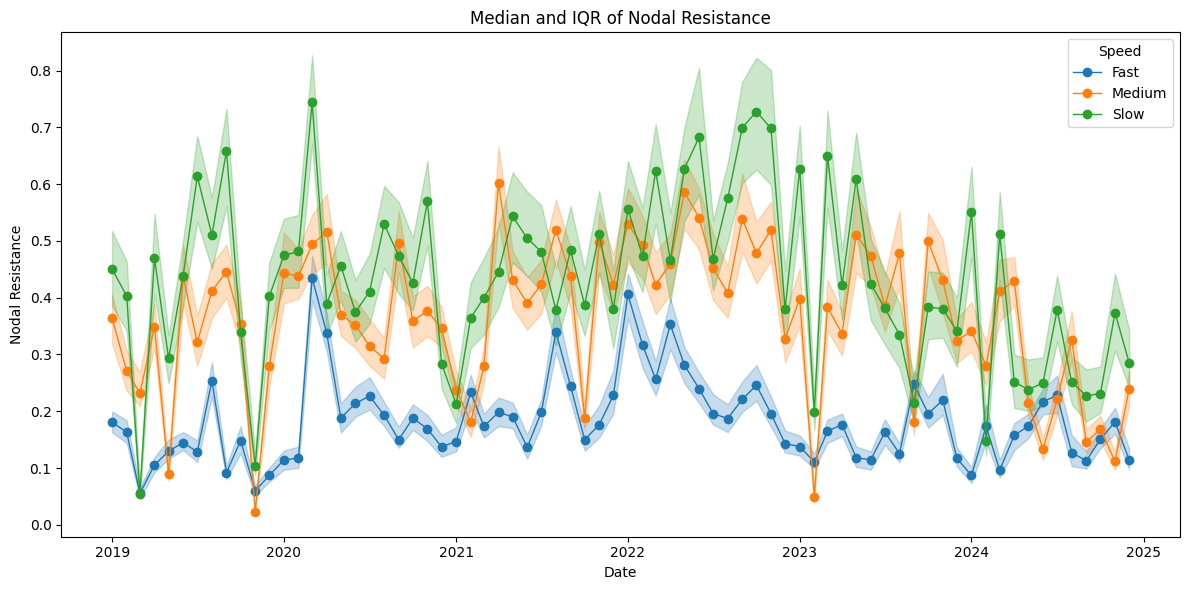

In [125]:
q = ( 
    df.groupby(["year_month_dt", "speed"])["nodal_resistance"] 
    .quantile([0.25, 0.5, 0.75]) 
    .unstack() 
    .reset_index() 
    )
q.columns = ["year_month_dt", "speed", "q25", "q50", "q75"]

# speeds em ordem fixa (importante para consistência)
speeds = sorted(q["speed"].unique())

# extrair cores da paleta Set2
# paleta com mais contraste
palette = sns.color_palette("tab10", n_colors=len(speeds))
color_map = dict(zip(speeds, palette))

# mapear speed -> cor
color_map = dict(zip(speeds, palette))

plt.figure(figsize=(12,6))

for speed in speeds:
    d = q[q["speed"] == speed].sort_values("year_month_dt")
    c = color_map[speed]

    # banda Q25–Q75
    plt.fill_between(
        d["year_month_dt"],
        d["q25"],
        d["q75"],
        color=c,
        alpha=0.25
    )

    # mediana
    plt.plot(
        d["year_month_dt"],
        d["q50"],
        color=c,
        linewidth=1,
        marker="o",
        label=speed
    )

plt.xlabel("Date")
plt.ylabel("Nodal Resistance")
plt.title("Median and IQR of Nodal Resistance")
plt.legend(title="Speed")
plt.xticks()
plt.tight_layout()
plt.show()

Fast < Medium < Slow

Fast mode: rede mais integrada, menor resistência. 
Slow mode: rede mais fragmentada, maior resistência.

Choques rápidos se propagam por uma rede mais integrada, enquanto dinâmicas lentas operam sobre uma topologia mais fragmentada.

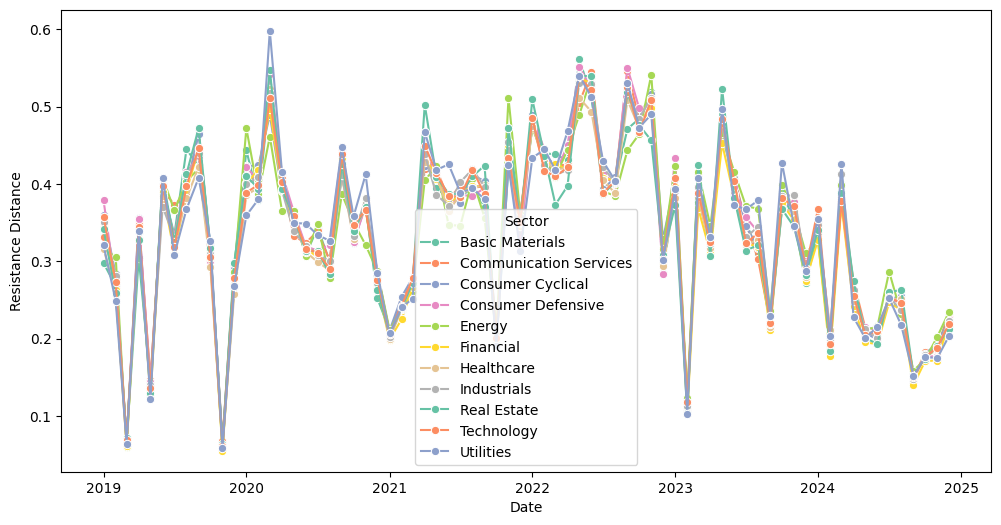

In [15]:
plt.figure(figsize=(12,6))

df_med = (
    df.groupby(["year_month_dt", "Sector"], as_index=False)
      .agg({"nodal_resistance": "median"})
)

sns.lineplot(
    data=df_med,
    x="year_month_dt",
    y="nodal_resistance",
    hue="Sector",
    palette="Set2",
    marker="o"
)

plt.legend(title="Sector")
plt.xlabel("Date")
plt.ylabel("Resistance Distance")
plt.show()

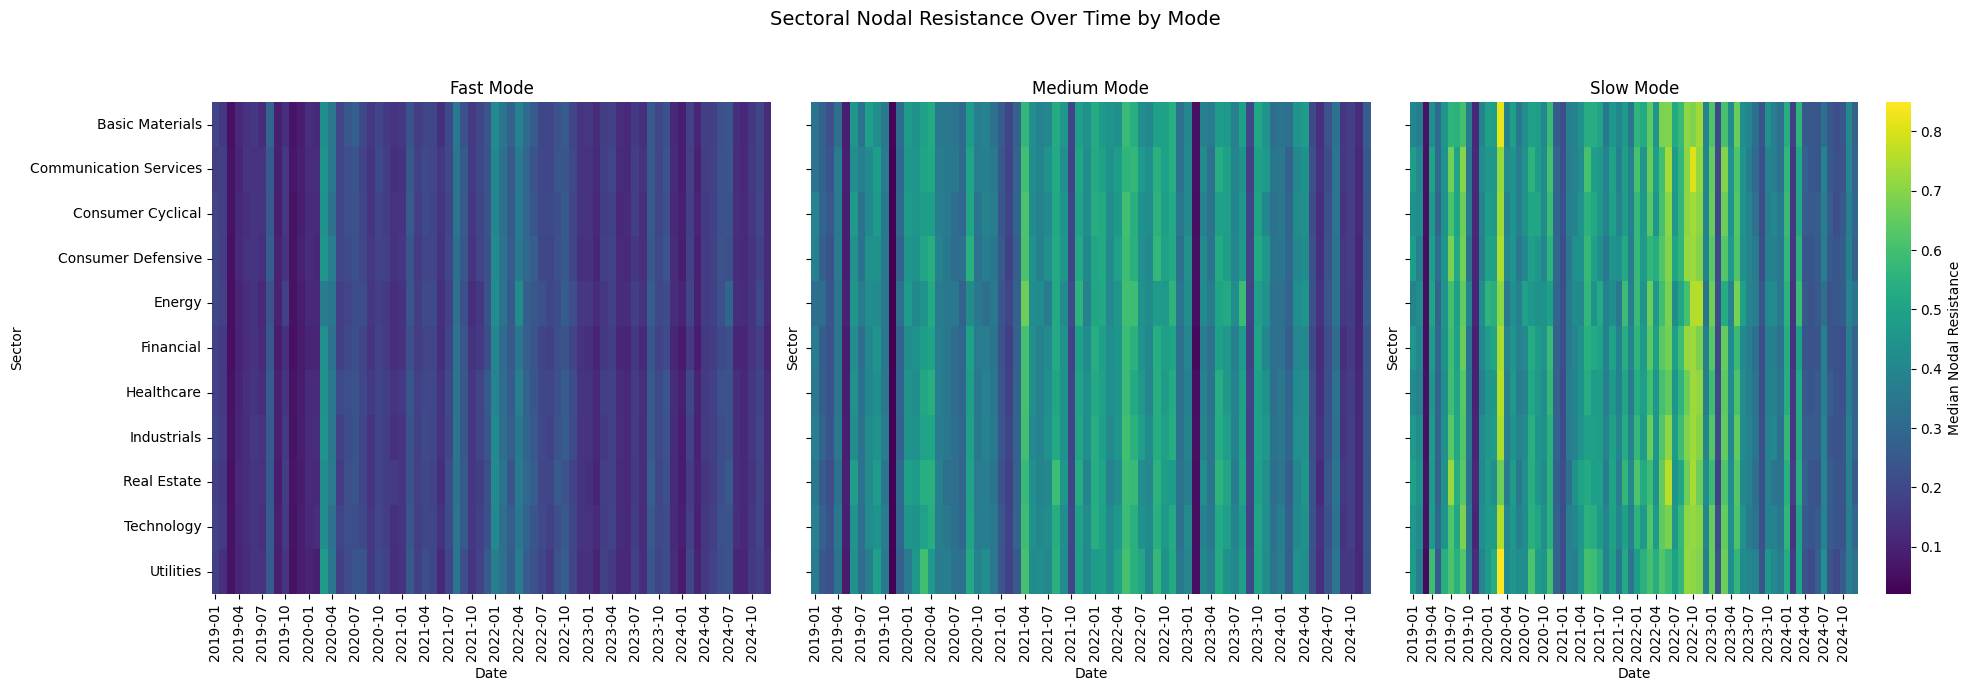

In [16]:
modes = ["Fast", "Medium", "Slow"]

# Calcular df_med por modo
df_med = (
    df.groupby(["year_month_dt", "Sector", "speed"], as_index=False)
      .agg({"nodal_resistance": "median"})
)

# Criar pivots por modo
pivots = {
    mode: df_med[df_med["speed"] == mode].pivot(
        index="Sector",
        columns="year_month_dt",
        values="nodal_resistance"
    )
    for mode in modes
}

# Escala comum de cores
vmin = min(p.min().min() for p in pivots.values())
vmax = max(p.max().max() for p in pivots.values())

fig, axes = plt.subplots(
    1, 3,
    figsize=(20, 7),
    sharey=True
)

for ax, mode in zip(axes, modes):
    sns.heatmap(
        pivots[mode],
        ax=ax,
        cmap="viridis",
        vmin=vmin,
        vmax=vmax,
        cbar=(mode == "Slow"),  # barra só no último
        cbar_kws={"label": "Median Nodal Resistance"} if mode == "Slow" else None
    )

    # Format x-ticks
    xticks = ax.get_xticks()
    xticklabels = [
        pivots[mode].columns[int(tick)].strftime("%Y-%m")
        if int(tick) < len(pivots[mode].columns) else ""
        for tick in xticks
    ]
    ax.set_xticklabels(xticklabels, rotation=90)

    ax.set_title(f"{mode} Mode")
    ax.set_xlabel("Date")

axes[0].set_ylabel("Sector")

plt.suptitle("Sectoral Nodal Resistance Over Time by Mode", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

Fast mode: pouca heterogeneidade setorial, setores andam juntos, baixa resistência. 

Medium mode: a heterogeneidade começa a aparecer.

Slow mode: maior diferença entre setores, resistência alta e persistente, picos longos. 

OBS: no início da pandemia, pico em todos os modos de resistência, indicando um choque onde o mercado fica mais fragmentado.

C:\Users\groque\AppData\Local\Temp\ipykernel_9352\152774215.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["year_month_dt", "mcap_bin"], as_index=False)


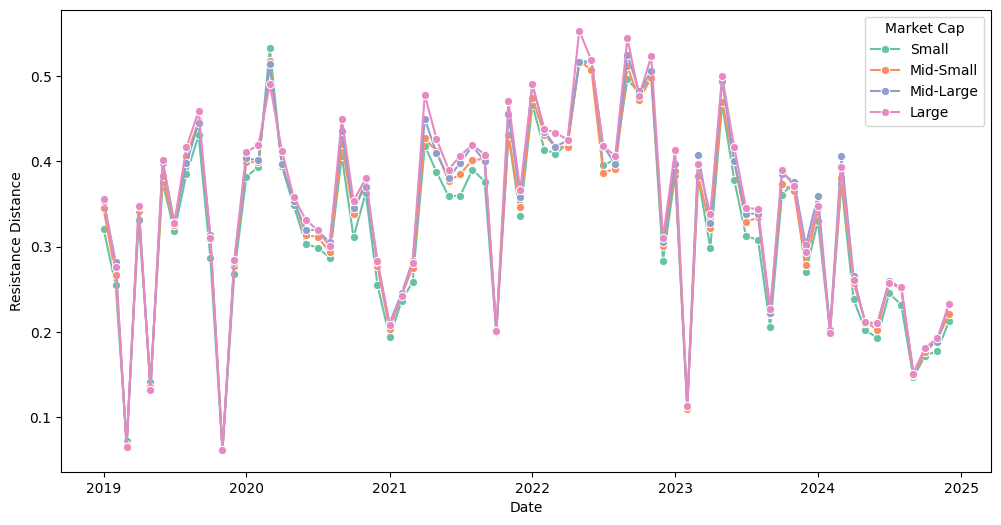

In [17]:
df["mcap_bin"] = (
    df.groupby("year_month_dt")["Market Cap"]
      .transform(lambda x: pd.qcut(
          x, q=4, labels=["Small", "Mid-Small", "Mid-Large", "Large"]
      ))
)

plt.figure(figsize=(12,6))

df_med = (
    df.groupby(["year_month_dt", "mcap_bin"], as_index=False)
      .agg({"nodal_resistance": "median"})
)

sns.lineplot(
    data=df_med,
    x="year_month_dt",
    y="nodal_resistance",
    hue="mcap_bin",
    palette="Set2",
    marker="o"
)

plt.legend(title="Market Cap")
plt.xlabel("Date")
plt.ylabel("Resistance Distance")
plt.show()

C:\Users\groque\AppData\Local\Temp\ipykernel_9352\233264478.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["year_month_dt", "mcap_bin", "speed"], as_index=False)


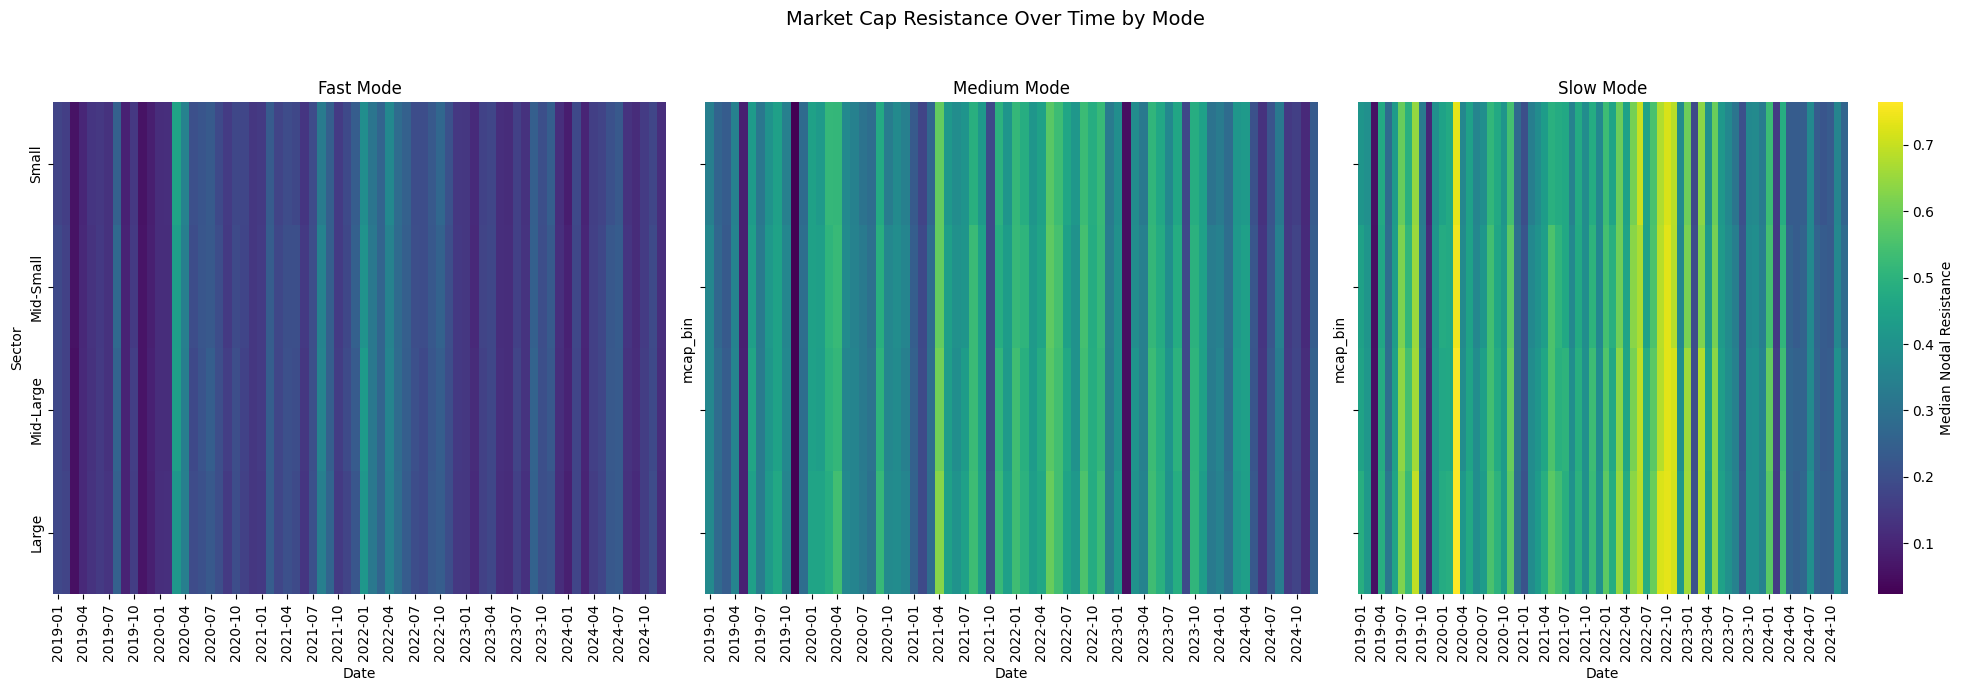

In [18]:
modes = ["Fast", "Medium", "Slow"]

# Calcular df_med por modo
df_med = (
    df.groupby(["year_month_dt", "mcap_bin", "speed"], as_index=False)
      .agg({"nodal_resistance": "median"})
)

# Criar pivots por modo
pivots = {
    mode: df_med[df_med["speed"] == mode].pivot(
        index="mcap_bin",
        columns="year_month_dt",
        values="nodal_resistance"
    )
    for mode in modes
}

# Escala comum de cores
vmin = min(p.min().min() for p in pivots.values())
vmax = max(p.max().max() for p in pivots.values())

fig, axes = plt.subplots(
    1, 3,
    figsize=(20, 7),
    sharey=True
)

for ax, mode in zip(axes, modes):
    sns.heatmap(
        pivots[mode],
        ax=ax,
        cmap="viridis",
        vmin=vmin,
        vmax=vmax,
        cbar=(mode == "Slow"),  # barra só no último
        cbar_kws={"label": "Median Nodal Resistance"} if mode == "Slow" else None
    )

    # Format x-ticks
    xticks = ax.get_xticks()
    xticklabels = [
        pivots[mode].columns[int(tick)].strftime("%Y-%m")
        if int(tick) < len(pivots[mode].columns) else ""
        for tick in xticks
    ]
    ax.set_xticklabels(xticklabels, rotation=90)

    ax.set_title(f"{mode} Mode")
    ax.set_xlabel("Date")

axes[0].set_ylabel("Sector")

plt.suptitle("Market Cap Resistance Over Time by Mode", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

Nenhum grupo de Market Cap domina ou se distingue muito em relação à resistência, mostrando que a capitalização das empresas não tem influência na distância do ativo na rede, seguindo muito mais tendências temporais do que uma tendência relativa à capitalização em si. O mesmo também vale pra setores. 

No caso dos modos, Slow mode novamente possui os maiores valores de resistência nodal mediano, indicando que no longo prazo as redes financeiras apresentam nós mais distantes entre si, com menos caminhos alternativos e menor integração sistêmica.

## Análise 3: Clustering

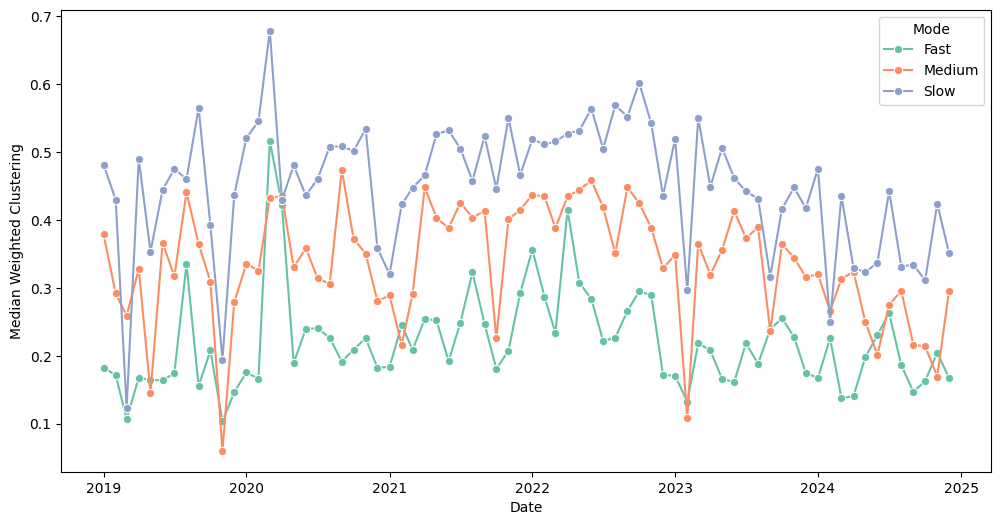

In [62]:
plt.figure(figsize=(12,6))

df_med = (
    df.groupby(["year_month_dt", "speed"], as_index=False)
      .agg({"weighted_clustering": "median"})
)

sns.lineplot(
    data=df_med,
    x="year_month_dt",
    y="weighted_clustering",
    hue="speed",
    palette="Set2",
    marker="o"
)

plt.legend(title="Mode")
plt.xlabel("Date")
plt.ylabel("Median Weighted Clustering")
plt.show()

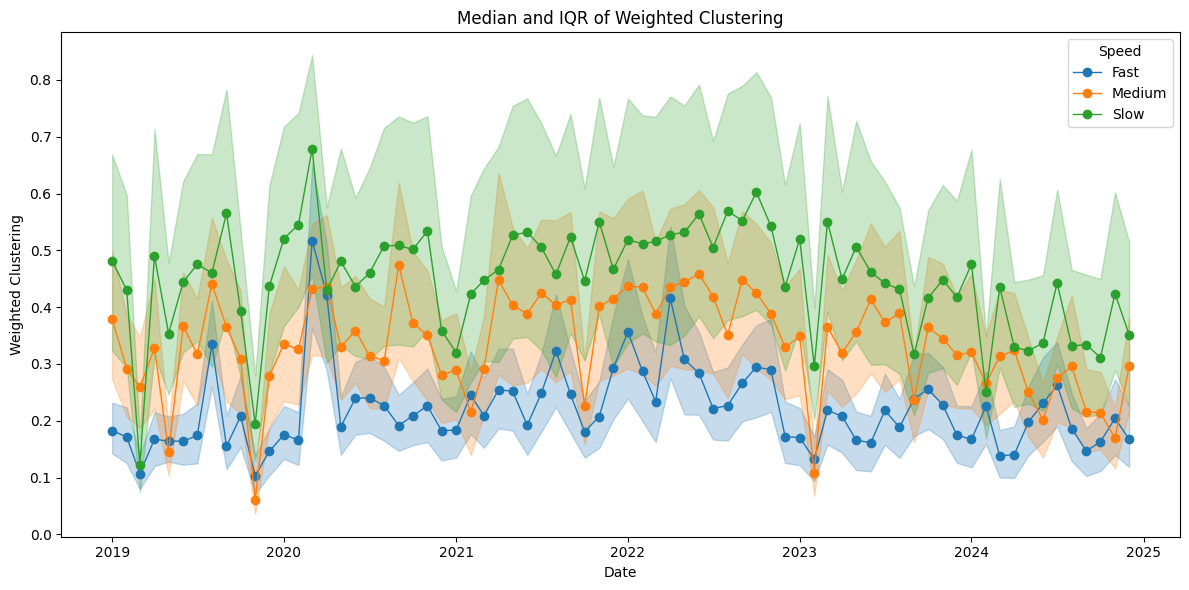

In [128]:
q = ( 
    df.groupby(["year_month_dt", "speed"])["weighted_clustering"] 
    .quantile([0.25, 0.5, 0.75]) 
    .unstack() 
    .reset_index() 
    )
q.columns = ["year_month_dt", "speed", "q25", "q50", "q75"]

# speeds em ordem fixa (importante para consistência)
speeds = sorted(q["speed"].unique())

# extrair cores da paleta Set2
# paleta com mais contraste
palette = sns.color_palette("tab10", n_colors=len(speeds))
color_map = dict(zip(speeds, palette))

# mapear speed -> cor
color_map = dict(zip(speeds, palette))

plt.figure(figsize=(12,6))

for speed in speeds:
    d = q[q["speed"] == speed].sort_values("year_month_dt")
    c = color_map[speed]

    # banda Q25–Q75
    plt.fill_between(
        d["year_month_dt"],
        d["q25"],
        d["q75"],
        color=c,
        alpha=0.25
    )

    # mediana
    plt.plot(
        d["year_month_dt"],
        d["q50"],
        color=c,
        linewidth=1,
        marker="o",
        label=speed
    )

plt.xlabel("Date")
plt.ylabel("Weighted Clustering")
plt.title("Median and IQR of Weighted Clustering")
plt.legend(title="Speed")
plt.xticks()
plt.tight_layout()
plt.show()

Alto weighted clustering mediano do slow mode indica uma forte segmentação de mercado, presença de setores coesos, risco sistêmico local onde choques se propagam facilmente e menor potencial de diversificação. 

O baixo weighted clustering mediano do fast mode indica ativos mais independentes entre si, com maior potencial de diversificação e menor contágio financeiro local. 

Slow mode apresenta maior formação de clusters, enquanto Fast mode menor formação de clusters, com ativos mais independentes. 

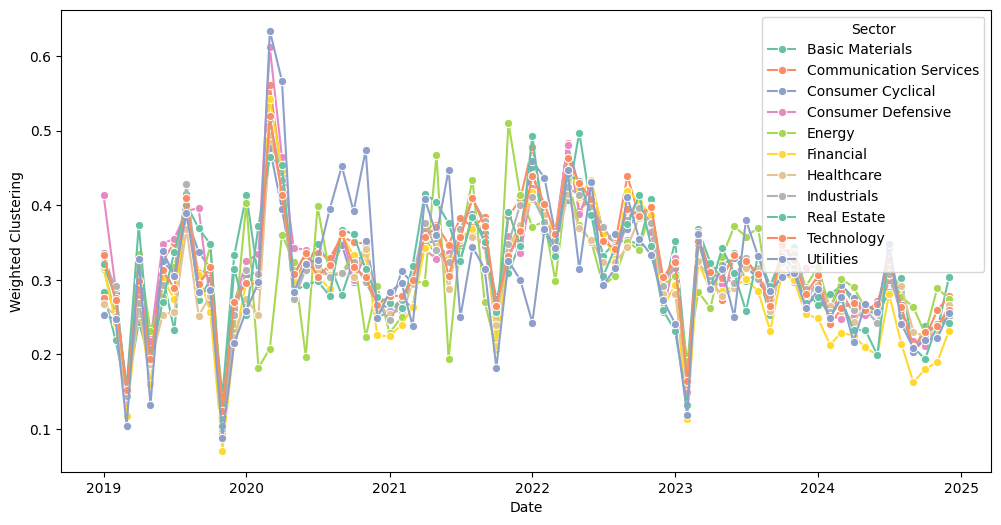

In [20]:
plt.figure(figsize=(12,6))

df_med = (
    df.groupby(["year_month_dt", "Sector"], as_index=False)
      .agg({"weighted_clustering": "median"})
)

sns.lineplot(
    data=df_med,
    x="year_month_dt",
    y="weighted_clustering",
    hue="Sector",
    palette="Set2",
    marker="o"
)

plt.legend(title="Sector")
plt.xlabel("Date")
plt.ylabel("Weighted Clustering")
plt.show()

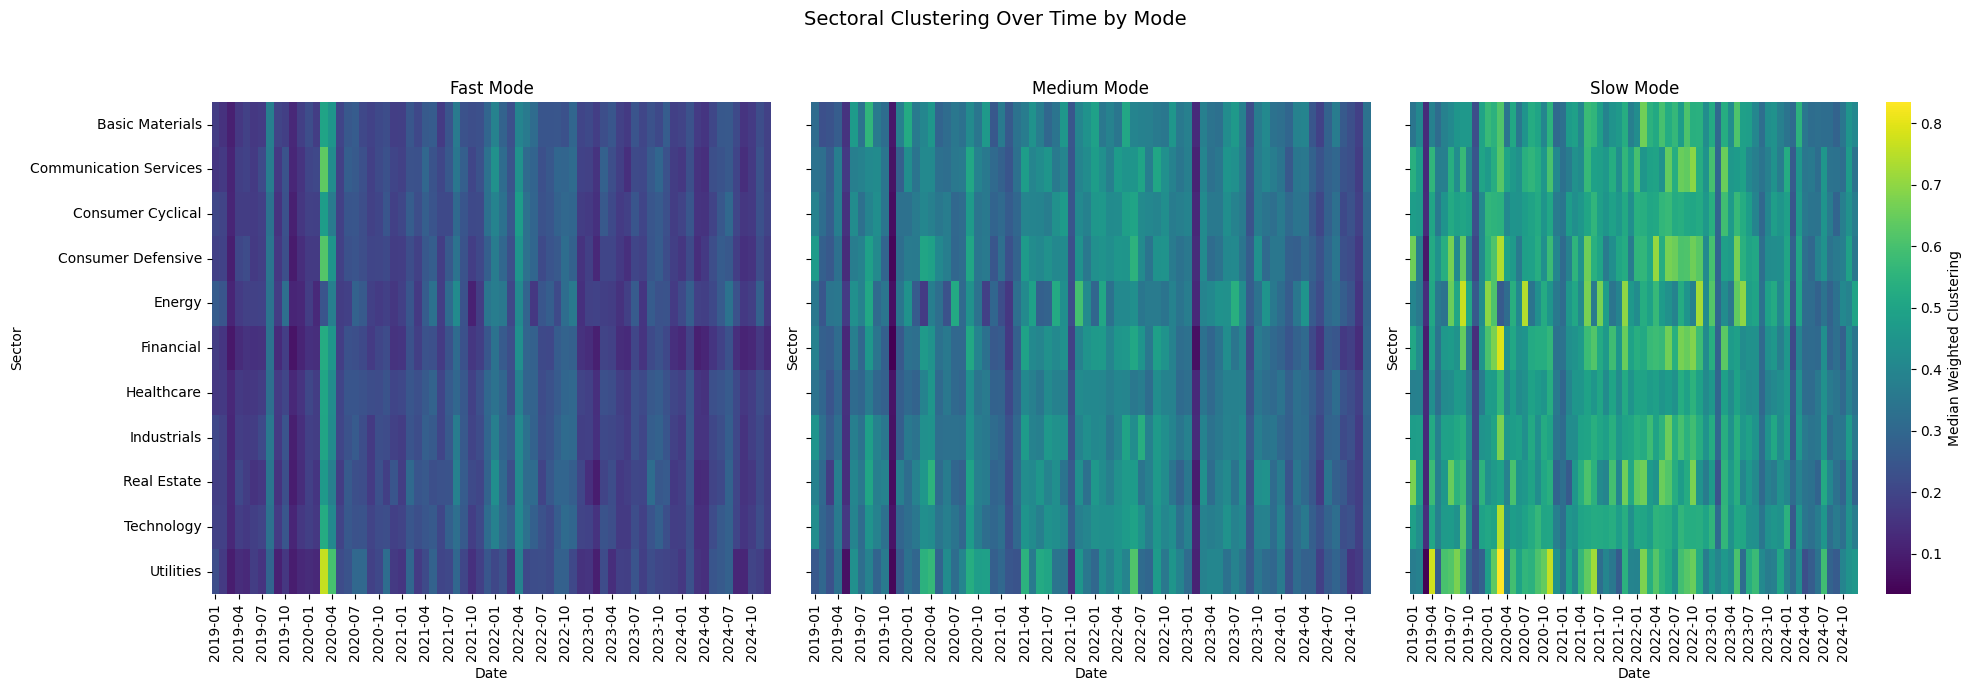

In [68]:
modes = ["Fast", "Medium", "Slow"]

# Calcular df_med por modo
df_med = (
    df.groupby(["year_month_dt", "Sector", "speed"], as_index=False)
      .agg({"weighted_clustering": "median"})
)

# Criar pivots por modo
pivots = {
    mode: df_med[df_med["speed"] == mode].pivot(
        index="Sector",
        columns="year_month_dt",
        values="weighted_clustering"
    )
    for mode in modes
}

# Escala comum de cores
vmin = min(p.min().min() for p in pivots.values())
vmax = max(p.max().max() for p in pivots.values())

fig, axes = plt.subplots(
    1, 3,
    figsize=(20, 7),
    sharey=True
)

for ax, mode in zip(axes, modes):
    sns.heatmap(
        pivots[mode],
        ax=ax,
        cmap="viridis",
        vmin=vmin,
        vmax=vmax,
        cbar=(mode == "Slow"),  # barra só no último
        cbar_kws={"label": "Median Weighted Clustering"} if mode == "Slow" else None
    )

    # Format x-ticks
    xticks = ax.get_xticks()
    xticklabels = [
        pivots[mode].columns[int(tick)].strftime("%Y-%m")
        if int(tick) < len(pivots[mode].columns) else ""
        for tick in xticks
    ]
    ax.set_xticklabels(xticklabels, rotation=90)

    ax.set_title(f"{mode} Mode")
    ax.set_xlabel("Date")

axes[0].set_ylabel("Sector")

plt.suptitle("Sectoral Clustering Over Time by Mode", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

Fast mode: diferenças entre os setores já são visíveis apesar do menor coeficiente. Setor de energia não parece seguir a tendência de outros, apresentando uma tendência própria. Setor de utilities também, apresentando coeficiente maior do que outros setores, maior formação de clusters. 

Medium mode: setor de energia novamente não segue a tendência geral. 

Fast mode: setor de energia parece seguir uma tendência própria/reversa, setor financeiro, tecnologia e utilidades reagem mais fortemente ao choque de 2020, enquanto que setor energético reage de maneira reversa, diminuindo o coeficiente.

C:\Users\groque\AppData\Local\Temp\ipykernel_9352\2890251909.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["year_month_dt", "mcap_bin", "speed"], as_index=False)


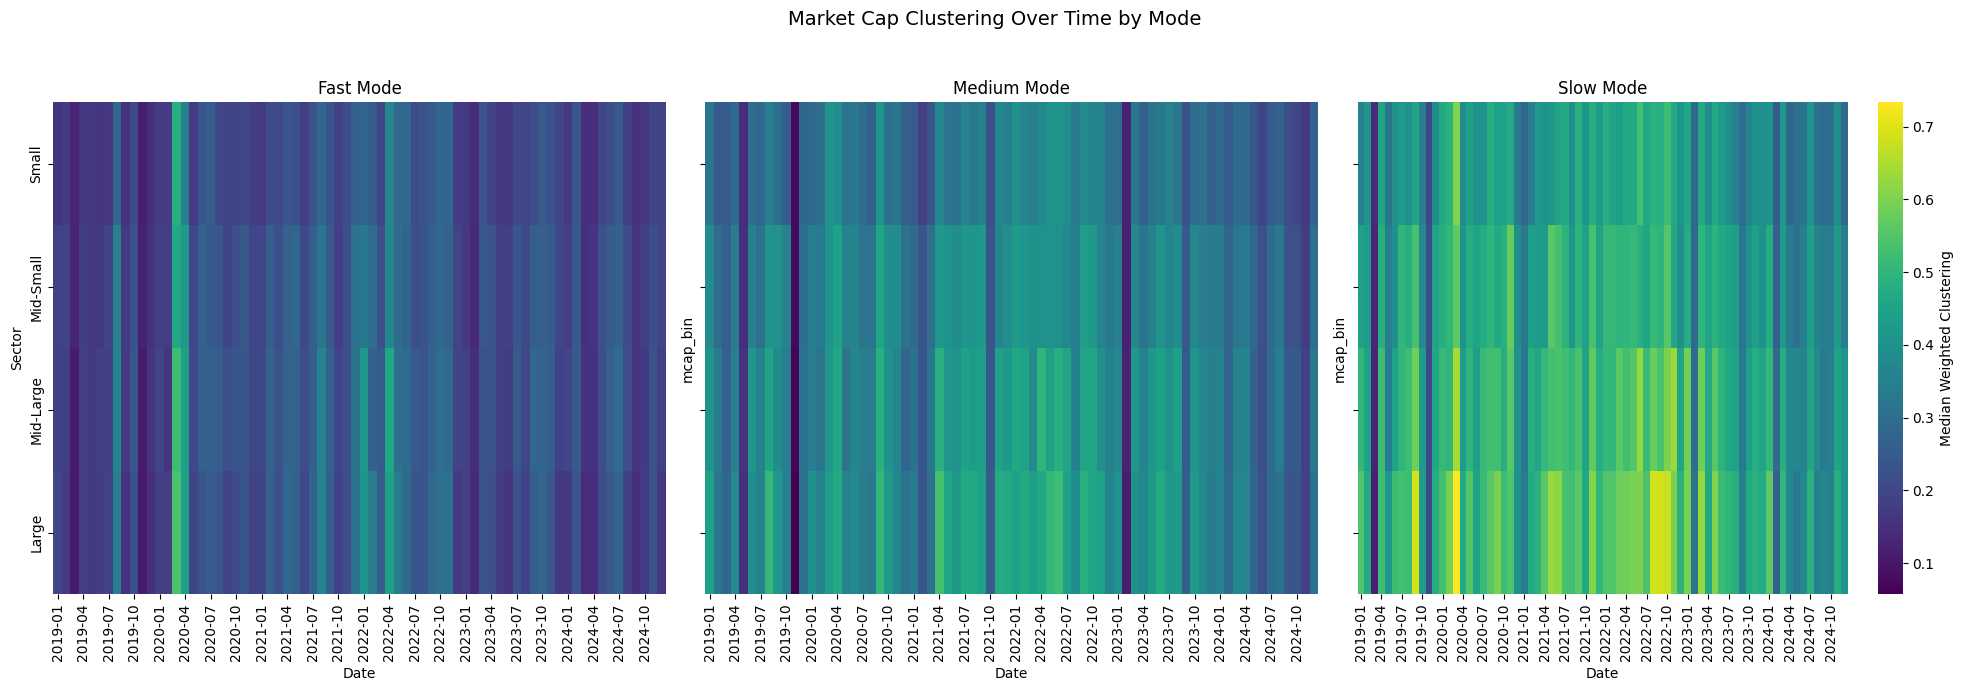

In [22]:
df["mcap_bin"] = (
    df.groupby("year_month_dt")["Market Cap"]
      .transform(lambda x: pd.qcut(
          x, q=4, labels=["Small", "Mid-Small", "Mid-Large", "Large"]
      ))
)

modes = ["Fast", "Medium", "Slow"]

# Calcular df_med por modo
df_med = (
    df.groupby(["year_month_dt", "mcap_bin", "speed"], as_index=False)
      .agg({"weighted_clustering": "median"})
)

# Criar pivots por modo
pivots = {
    mode: df_med[df_med["speed"] == mode].pivot(
        index="mcap_bin",
        columns="year_month_dt",
        values="weighted_clustering"
    )
    for mode in modes
}

# Escala comum de cores
vmin = min(p.min().min() for p in pivots.values())
vmax = max(p.max().max() for p in pivots.values())

fig, axes = plt.subplots(
    1, 3,
    figsize=(20, 7),
    sharey=True
)

for ax, mode in zip(axes, modes):
    sns.heatmap(
        pivots[mode],
        ax=ax,
        cmap="viridis",
        vmin=vmin,
        vmax=vmax,
        cbar=(mode == "Slow"),  # barra só no último
        cbar_kws={"label": "Median Weighted Clustering"} if mode == "Slow" else None
    )

    # Format x-ticks
    xticks = ax.get_xticks()
    xticklabels = [
        pivots[mode].columns[int(tick)].strftime("%Y-%m")
        if int(tick) < len(pivots[mode].columns) else ""
        for tick in xticks
    ]
    ax.set_xticklabels(xticklabels, rotation=90)

    ax.set_title(f"{mode} Mode")
    ax.set_xlabel("Date")

axes[0].set_ylabel("Sector")

plt.suptitle("Market Cap Clustering Over Time by Mode", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

Fast mode: Large e Mid-Large com maiores valores do coeficiente de clustering mediano, indicando que essas capitalizações tendem a se conectar mais em clusters nesse modo. 

Medium mode: Os Mid-Small e Small começam a se conectar mais em clusters, mas ainda é dominado por maiores capitalizações. 

Slow mode: Mesma interpretação do Medium. Large se destaca muito dos demais como o maior coeficiente de clustering.

C:\Users\groque\AppData\Local\Temp\ipykernel_9352\685173851.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["year_month_dt", "mcap_bin"], as_index=False)


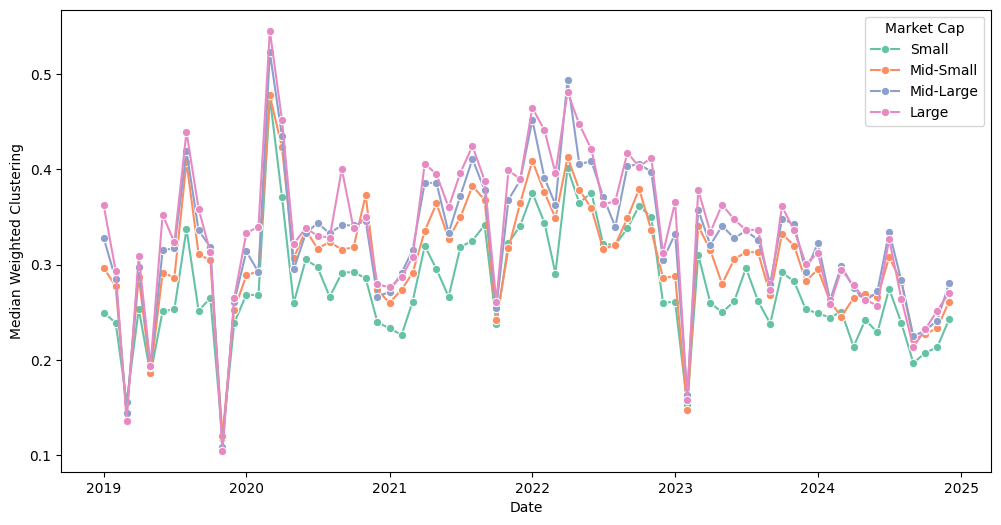

In [63]:
df["mcap_bin"] = (
    df.groupby("year_month_dt")["Market Cap"]
      .transform(lambda x: pd.qcut(
          x, q=4, labels=["Small", "Mid-Small", "Mid-Large", "Large"]
      ))
)

plt.figure(figsize=(12,6))

df_med = (
    df.groupby(["year_month_dt", "mcap_bin"], as_index=False)
      .agg({"weighted_clustering": "median"})
)

sns.lineplot(
    data=df_med,
    x="year_month_dt",
    y="weighted_clustering",
    hue="mcap_bin",
    palette="Set2",
    marker="o"
)

plt.legend(title="Market Cap")
plt.xlabel("Date")
plt.ylabel("Median Weighted Clustering")
plt.show()

## Análise 4 - Betweenness

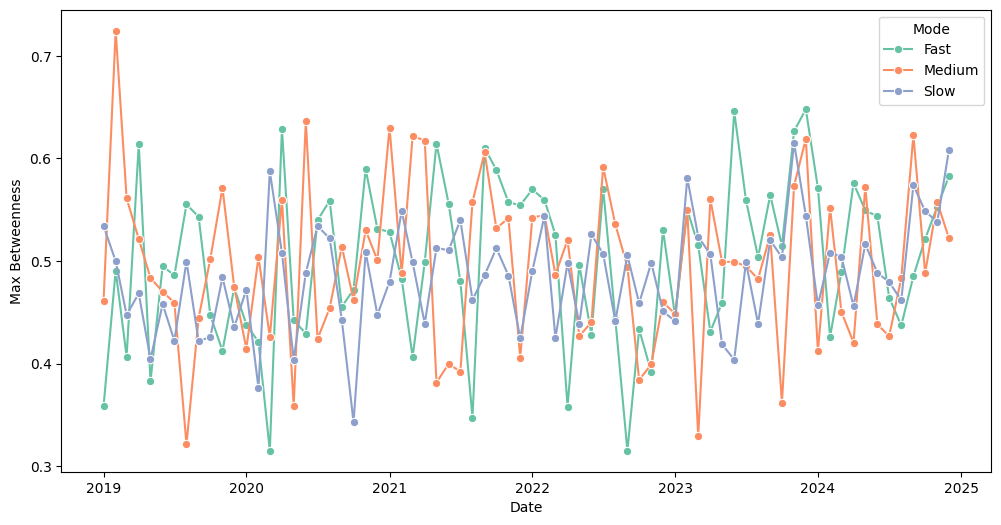

In [75]:
plt.figure(figsize=(12,6))

df_med = (
    df.groupby(["year_month_dt", "speed"], as_index=False)
      .agg({"betweenness": "max"})
)

sns.lineplot(
    data=df_med,
    x="year_month_dt",
    y="betweenness",
    hue="speed",
    palette="Set2",
    marker="o"
)

plt.legend(title="Mode")
plt.xlabel("Date")
plt.ylabel("Max Betweenness")
plt.show()

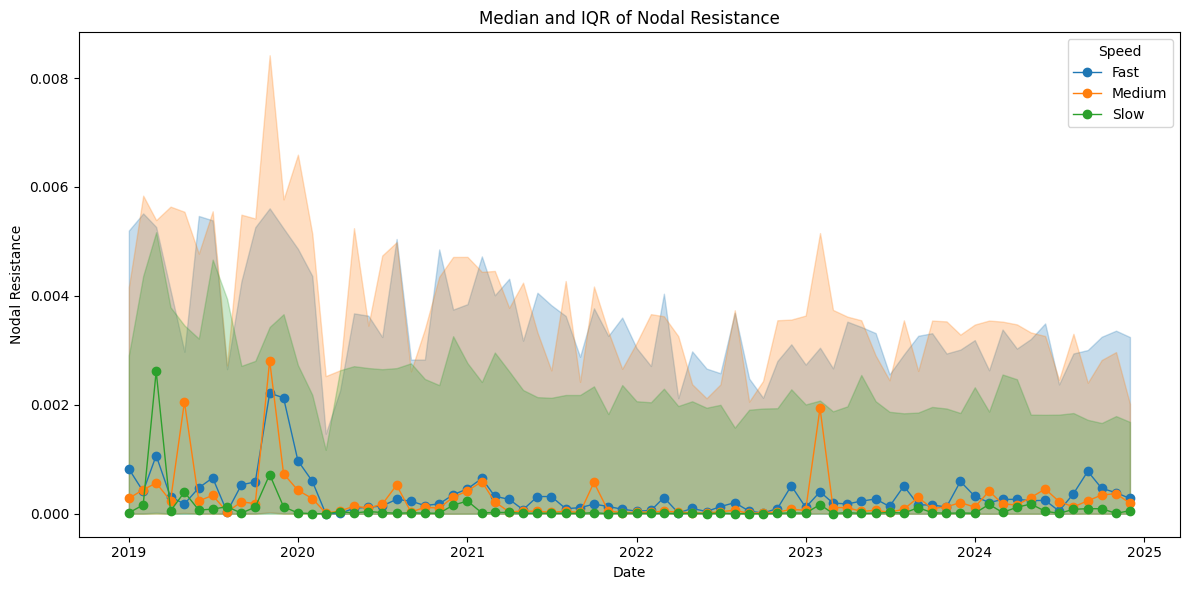

In [130]:
q = ( 
    df.groupby(["year_month_dt", "speed"])["betweenness"] 
    .quantile([0.25, 0.5, 0.75]) 
    .unstack() 
    .reset_index() 
    )
q.columns = ["year_month_dt", "speed", "q25", "q50", "q75"]

# speeds em ordem fixa (importante para consistência)
speeds = sorted(q["speed"].unique())

# extrair cores da paleta Set2
# paleta com mais contraste
palette = sns.color_palette("tab10", n_colors=len(speeds))
color_map = dict(zip(speeds, palette))

# mapear speed -> cor
color_map = dict(zip(speeds, palette))

plt.figure(figsize=(12,6))

for speed in speeds:
    d = q[q["speed"] == speed].sort_values("year_month_dt")
    c = color_map[speed]

    # banda Q25–Q75
    plt.fill_between(
        d["year_month_dt"],
        d["q25"],
        d["q75"],
        color=c,
        alpha=0.25
    )

    # mediana
    plt.plot(
        d["year_month_dt"],
        d["q50"],
        color=c,
        linewidth=1,
        marker="o",
        label=speed
    )

plt.xlabel("Date")
plt.ylabel("Nodal Resistance")
plt.title("Median and IQR of Nodal Resistance")
plt.legend(title="Speed")
plt.xticks()
plt.tight_layout()
plt.show()

Os resultados indicam que os modos Medium e Fast apresentam maior heterogeneidade estrutural ao longo do tempo, refletida na elevada variabilidade da betweenness centrality. Esses modos alternam entre períodos em que alguns ativos assumem papel de forte intermediação — atuando como pontes críticas na rede e potenciais canais de contágio financeiro — e períodos em que a estrutura se torna mais fragmentada, com ativos predominantemente periféricos e menor risco sistêmico local.

Em contraste, o Slow Mode exibe um comportamento mais estável e homogêneo, com menores flutuações da betweenness máxima ao longo do tempo. Essa consistência sugere uma dinâmica de longo prazo mais descentralizada, na qual o papel de intermediação é distribuído entre os ativos, reduzindo a dependência do sistema em nós específicos.

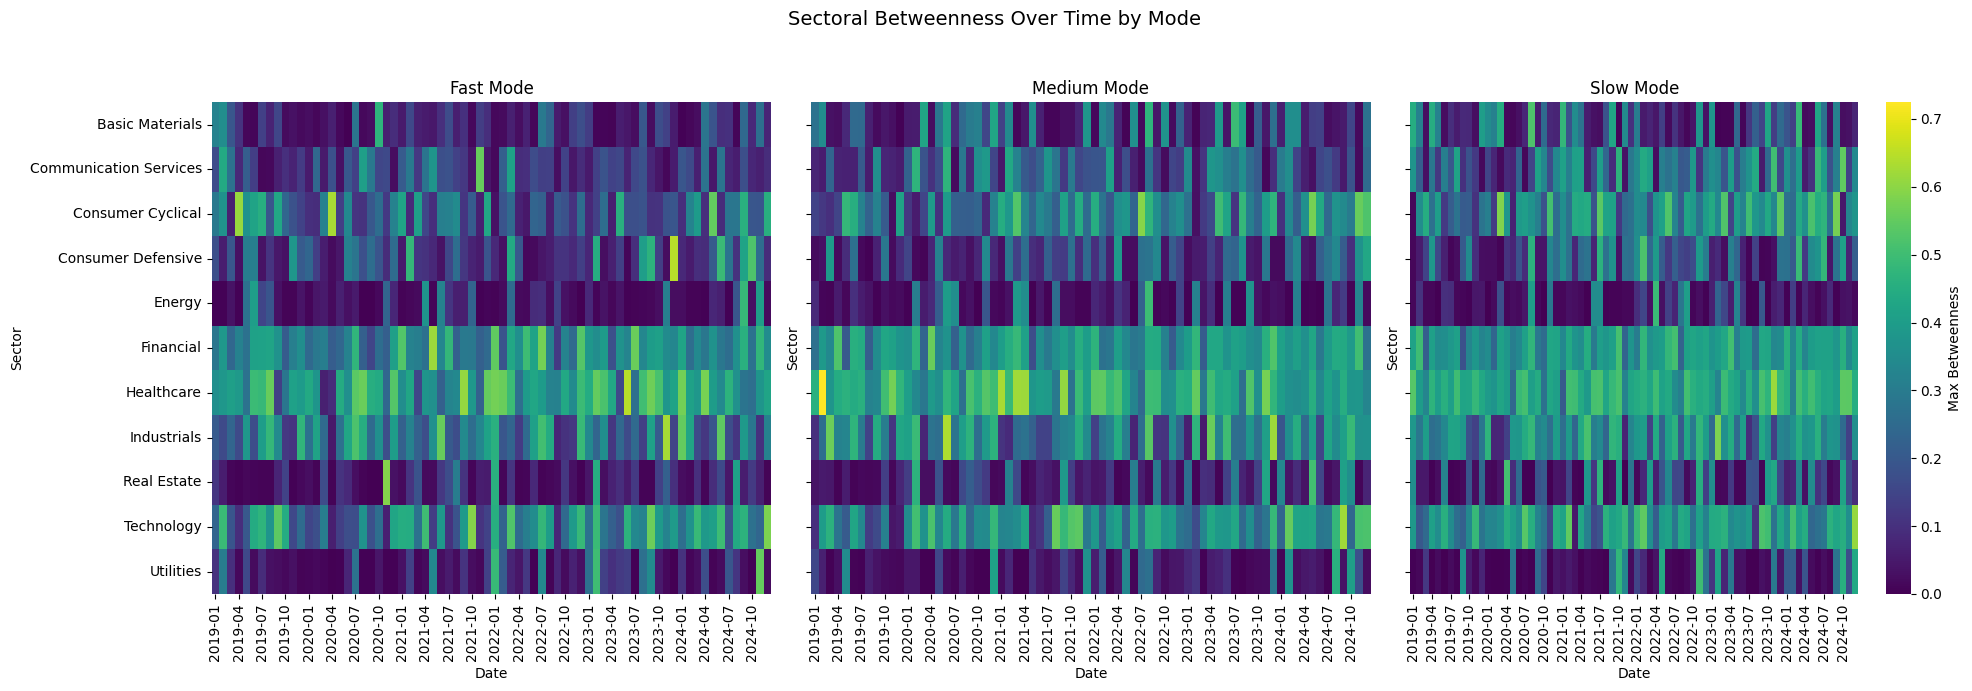

In [132]:
modes = ["Fast", "Medium", "Slow"]

# Calcular df_med por modo
df_med = (
    df.groupby(["year_month_dt", "Sector", "speed"], as_index=False)
      .agg({"betweenness": "max"})
)

# Criar pivots por modo
pivots = {
    mode: df_med[df_med["speed"] == mode].pivot(
        index="Sector",
        columns="year_month_dt",
        values="betweenness"
    )
    for mode in modes
}

# Escala comum de cores
vmin = min(p.min().min() for p in pivots.values())
vmax = max(p.max().max() for p in pivots.values())

fig, axes = plt.subplots(
    1, 3,
    figsize=(20, 7),
    sharey=True
)

for ax, mode in zip(axes, modes):
    sns.heatmap(
        pivots[mode],
        ax=ax,
        cmap="viridis",
        vmin=vmin,
        vmax=vmax,
        cbar=(mode == "Slow"),  # barra só no último
        cbar_kws={"label": "Max Betweenness"} if mode == "Slow" else None
    )

    # Format x-ticks
    xticks = ax.get_xticks()
    xticklabels = [
        pivots[mode].columns[int(tick)].strftime("%Y-%m")
        if int(tick) < len(pivots[mode].columns) else ""
        for tick in xticks
    ]
    ax.set_xticklabels(xticklabels, rotation=90)

    ax.set_title(f"{mode} Mode")
    ax.set_xlabel("Date")

axes[0].set_ylabel("Sector")

plt.suptitle("Sectoral Betweenness Over Time by Mode", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

Setores bem diferenciados quanto ao betweenness centrality máximo. Destaque para o setor financeiro e de saúde como maiores valores de betweenness de forma estável ao longo do tempo, indicando que ativos desses setores são cruciais para conectar a rede financeira. Do contrário, o setor de energia apresenta os menores valores de betweenness máximo, mostrando que são ativos mais periféricos e menos relevantes para a rede.

C:\Users\groque\AppData\Local\Temp\ipykernel_9352\3900773203.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["year_month_dt", "mcap_bin", "speed"], as_index=False)


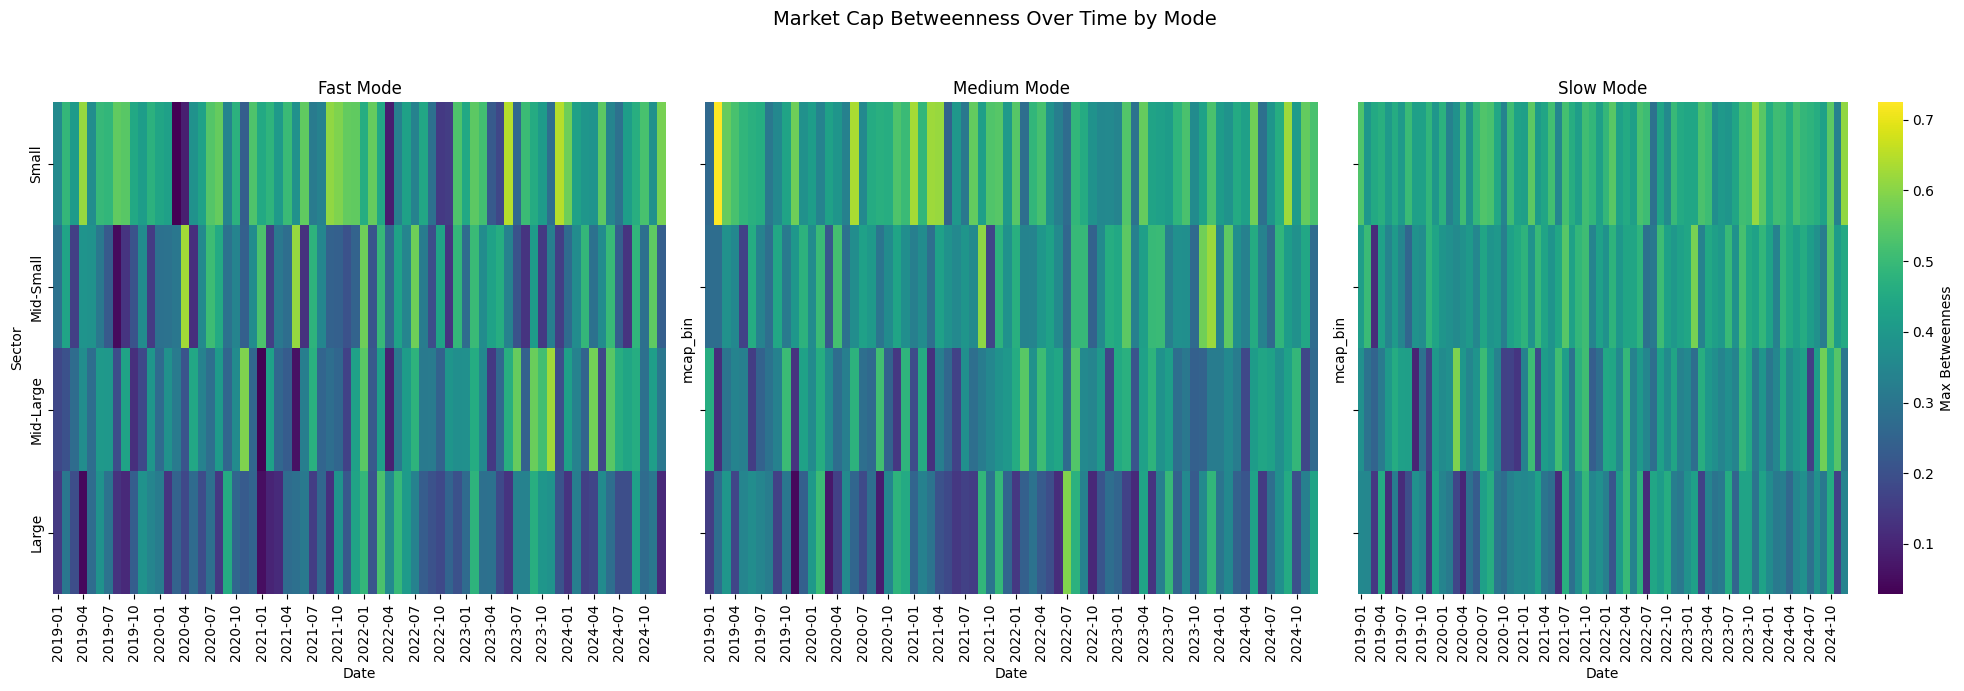

In [133]:
df["mcap_bin"] = (
    df.groupby("year_month_dt")["Market Cap"]
      .transform(lambda x: pd.qcut(
          x, q=4, labels=["Small", "Mid-Small", "Mid-Large", "Large"]
      ))
)

modes = ["Fast", "Medium", "Slow"]

# Calcular df_med por modo
df_med = (
    df.groupby(["year_month_dt", "mcap_bin", "speed"], as_index=False)
      .agg({"betweenness": "max"})
)

# Criar pivots por modo
pivots = {
    mode: df_med[df_med["speed"] == mode].pivot(
        index="mcap_bin",
        columns="year_month_dt",
        values="betweenness"
    )
    for mode in modes
}

# Escala comum de cores
vmin = min(p.min().min() for p in pivots.values())
vmax = max(p.max().max() for p in pivots.values())

fig, axes = plt.subplots(
    1, 3,
    figsize=(20, 7),
    sharey=True
)

for ax, mode in zip(axes, modes):
    sns.heatmap(
        pivots[mode],
        ax=ax,
        cmap="viridis",
        vmin=vmin,
        vmax=vmax,
        cbar=(mode == "Slow"),  # barra só no último
        cbar_kws={"label": "Max Betweenness"} if mode == "Slow" else None
    )

    # Format x-ticks
    xticks = ax.get_xticks()
    xticklabels = [
        pivots[mode].columns[int(tick)].strftime("%Y-%m")
        if int(tick) < len(pivots[mode].columns) else ""
        for tick in xticks
    ]
    ax.set_xticklabels(xticklabels, rotation=90)

    ax.set_title(f"{mode} Mode")
    ax.set_xlabel("Date")

axes[0].set_ylabel("Sector")

plt.suptitle("Market Cap Betweenness Over Time by Mode", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

Small Caps com maior betweenness máximo em todos os três modos. Modos mais similares, com a diferença de que o Slow parece um pouco mais constante no valor de betweenness entre os setores, especialmente no Small e Mid-small Caps, enquanto que Medium e Fast mode apresentam maior variabilidade desse coeficiente em cada grupo de capitalização, sendo mais propensos à choques que aumentam ou diminuem o valor abruptamente. Isso indica que o valor do máximo betweenness do slow mode tende a ser mais estável, nós tendem a não variar tanto quanto à importância estrutural, se mantendo algo mais estável no tempo.

## Análise 5 - Eigenvector

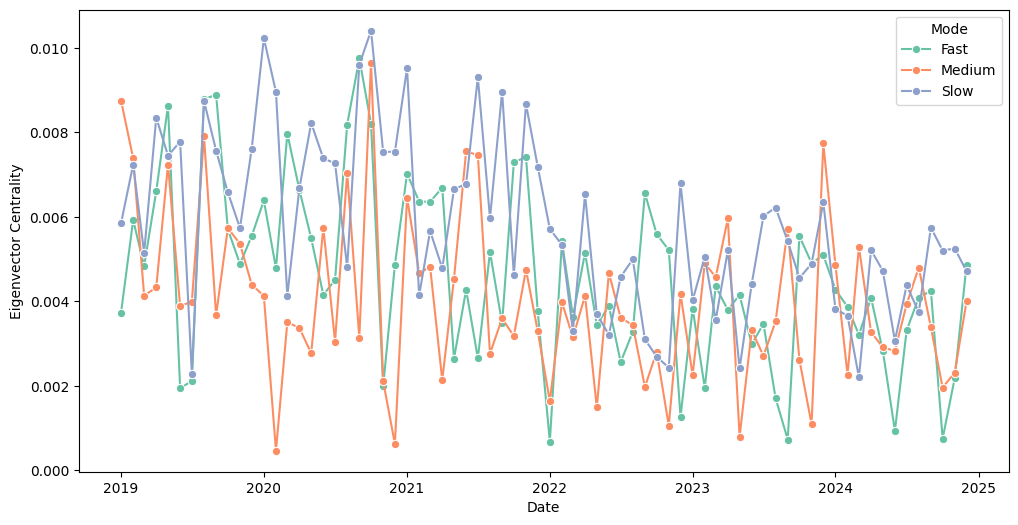

In [134]:
plt.figure(figsize=(12,6))

df_med = (
    df.groupby(["year_month_dt", "speed"], as_index=False)
      .agg({"eigenvector": "median"})
)

sns.lineplot(
    data=df_med,
    x="year_month_dt",
    y="eigenvector",
    hue="speed",
    palette="Set2",
    marker="o"
)

plt.legend(title="Mode")
plt.xlabel("Date")
plt.ylabel("Eigenvector Centrality")
plt.show()

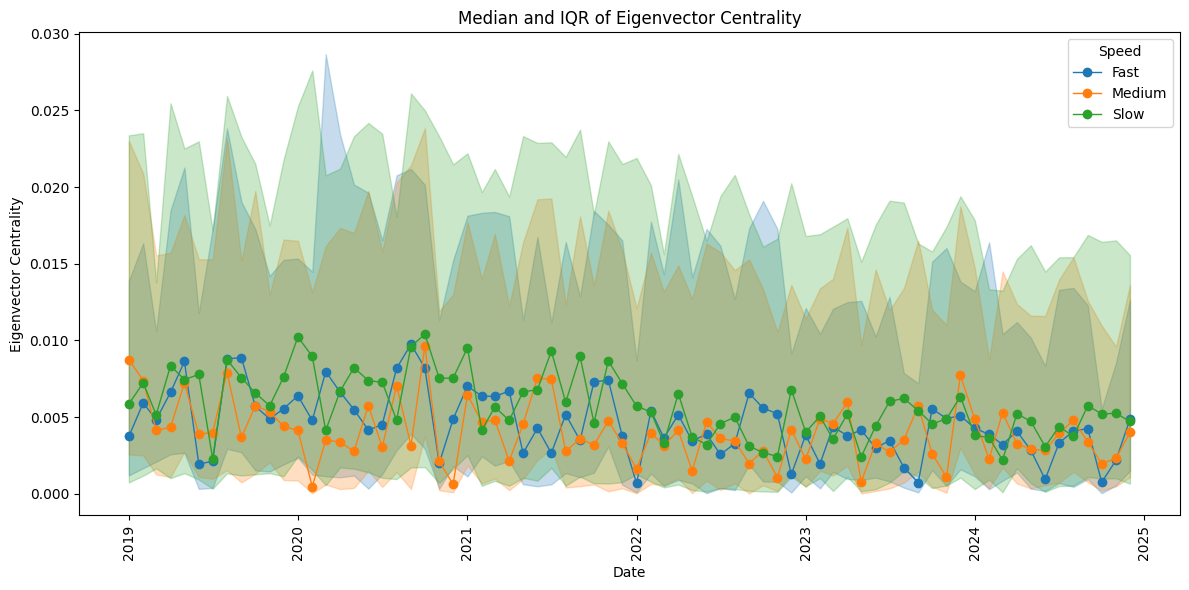

In [118]:
q = ( 
    df.groupby(["year_month_dt", "speed"])["eigenvector"] 
    .quantile([0.25, 0.5, 0.75]) 
    .unstack() 
    .reset_index() 
    )
q.columns = ["year_month_dt", "speed", "q25", "q50", "q75"]

# speeds em ordem fixa (importante para consistência)
speeds = sorted(q["speed"].unique())

# extrair cores da paleta Set2
# paleta com mais contraste
palette = sns.color_palette("tab10", n_colors=len(speeds))
color_map = dict(zip(speeds, palette))

# mapear speed -> cor
color_map = dict(zip(speeds, palette))

plt.figure(figsize=(12,6))

for speed in speeds:
    d = q[q["speed"] == speed].sort_values("year_month_dt")
    c = color_map[speed]

    # banda Q25–Q75
    plt.fill_between(
        d["year_month_dt"],
        d["q25"],
        d["q75"],
        color=c,
        alpha=0.25
    )

    # mediana
    plt.plot(
        d["year_month_dt"],
        d["q50"],
        color=c,
        linewidth=1,
        marker="o",
        label=speed
    )

plt.xlabel("Date")
plt.ylabel("Eigenvector Centrality")
plt.title("Median and IQR of Eigenvector Centrality")
plt.legend(title="Speed")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

Slow mode com maior eigenvector centrality, indicando que possui ativos conectados a outros ativos altamente correlacionados, representando fatores dominantes de mercado.
Fast Mode e Medium Mode apresentam padrão parecido, com bastante oscilação na distribuição, em alguns momentos até tendo valores maiores que o slow mode. No geral, porém, são intermediários, com valores menores de eigenvector centrality do que o Slow mode, indicando menos ativos conectados a ativos importantes, ativos mais conectados a ativos periféricos, com menor relevância sistêmica e maior potencial diversificador.

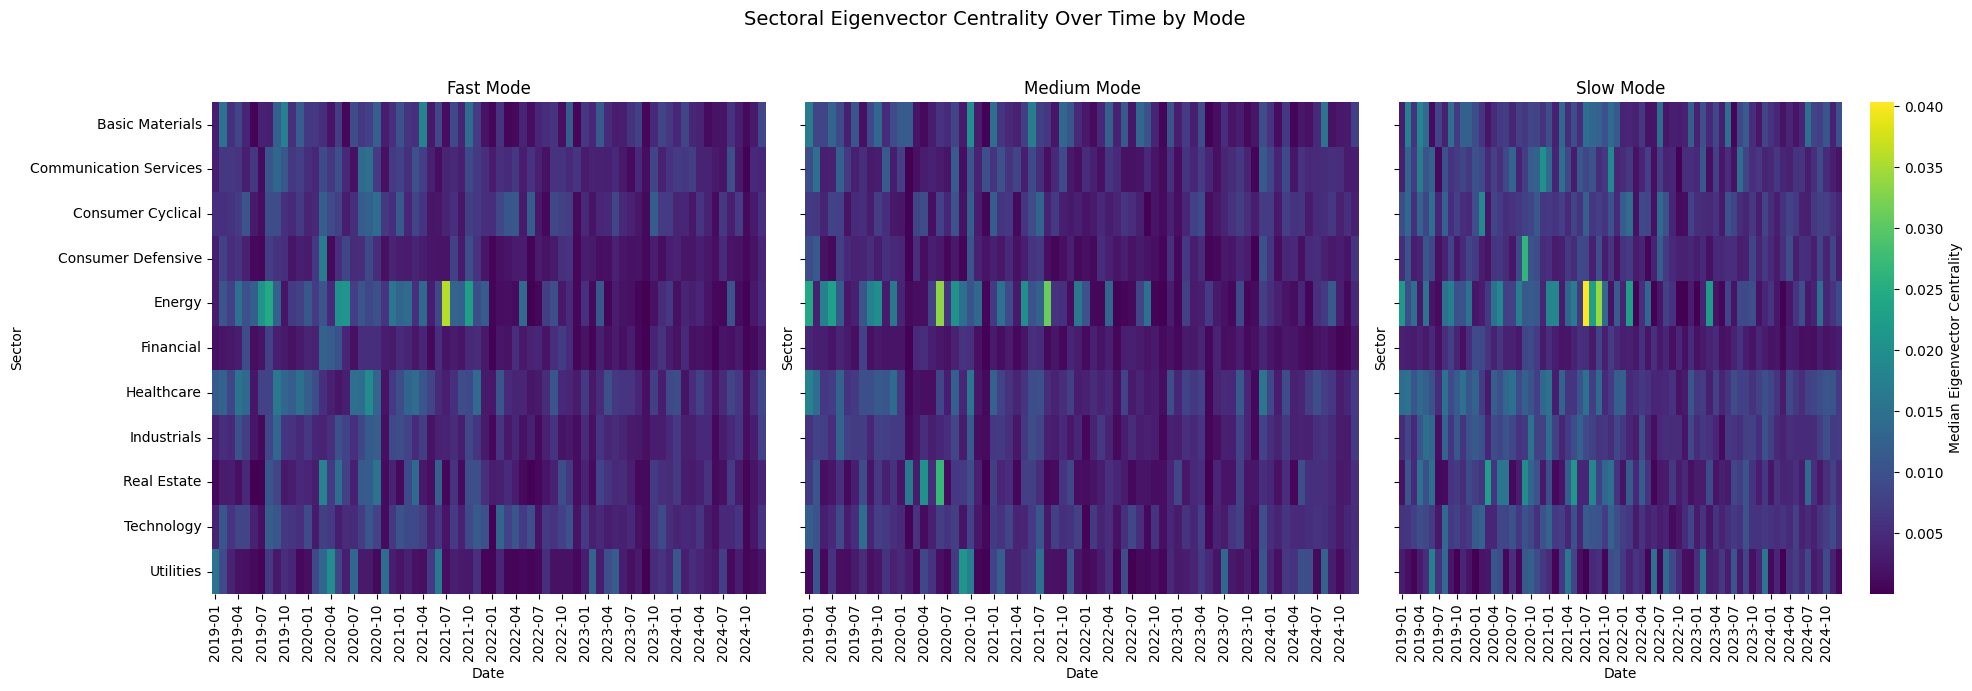

In [116]:
modes = ["Fast", "Medium", "Slow"]

# Calcular df_med por modo
df_med = (
    df.groupby(["year_month_dt", "Sector", "speed"], as_index=False)
      .agg({"eigenvector": "median"})
)

# Criar pivots por modo
pivots = {
    mode: df_med[df_med["speed"] == mode].pivot(
        index="Sector",
        columns="year_month_dt",
        values="eigenvector"
    )
    for mode in modes
}

# Escala comum de cores
vmin = min(p.min().min() for p in pivots.values())
vmax = max(p.max().max() for p in pivots.values())

fig, axes = plt.subplots(
    1, 3,
    figsize=(20, 7),
    sharey=True
)

for ax, mode in zip(axes, modes):
    sns.heatmap(
        pivots[mode],
        ax=ax,
        cmap="viridis",
        vmin=vmin,
        vmax=vmax,
        cbar=(mode == "Slow"),  # barra só no último
        cbar_kws={"label": "Median Eigenvector Centrality"} if mode == "Slow" else None
    )

    # Format x-ticks
    xticks = ax.get_xticks()
    xticklabels = [
        pivots[mode].columns[int(tick)].strftime("%Y-%m")
        if int(tick) < len(pivots[mode].columns) else ""
        for tick in xticks
    ]
    ax.set_xticklabels(xticklabels, rotation=90)

    ax.set_title(f"{mode} Mode")
    ax.set_xlabel("Date")

axes[0].set_ylabel("Sector")

plt.suptitle("Sectoral Eigenvector Centrality Over Time by Mode", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

Três modos bem próximos com relação à mediana do eigenvector centrality, com o slow apresentando claramente valores maiores. 
Setor de energia se destaca pelo maior eig centrality, indicando que se conecta com ativos mais importantes.

## Análise 6 - Closeness

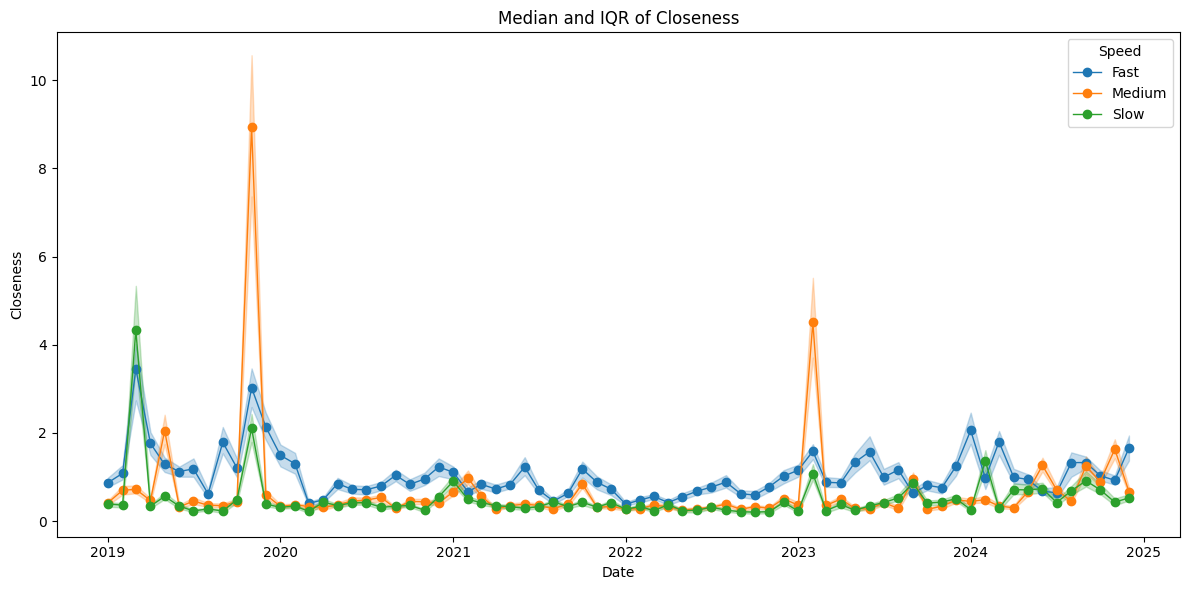

In [135]:
q = ( 
    df.groupby(["year_month_dt", "speed"])["closeness"] 
    .quantile([0.25, 0.5, 0.75]) 
    .unstack() 
    .reset_index() 
    )
q.columns = ["year_month_dt", "speed", "q25", "q50", "q75"]

# speeds em ordem fixa (importante para consistência)
speeds = sorted(q["speed"].unique())

# extrair cores da paleta Set2
# paleta com mais contraste
palette = sns.color_palette("tab10", n_colors=len(speeds))
color_map = dict(zip(speeds, palette))

# mapear speed -> cor
color_map = dict(zip(speeds, palette))

plt.figure(figsize=(12,6))

for speed in speeds:
    d = q[q["speed"] == speed].sort_values("year_month_dt")
    c = color_map[speed]

    # banda Q25–Q75
    plt.fill_between(
        d["year_month_dt"],
        d["q25"],
        d["q75"],
        color=c,
        alpha=0.25
    )

    # mediana
    plt.plot(
        d["year_month_dt"],
        d["q50"],
        color=c,
        linewidth=1,
        marker="o",
        label=speed
    )

plt.xlabel("Date")
plt.ylabel("Closeness")
plt.title("Median and IQR of Closeness")
plt.legend(title="Speed")
plt.xticks()
plt.tight_layout()
plt.show()

Fast mode: maior closeness indicando ativos mais bem posicionados na rede, mais próximos uns dos outros, recebendo choques mais rapidamente e reagindo cedo a mudanças de mercado. 

Medium mode: Em geral baixo closeness, mas com dois picos. 

Slow mode: Menor closeness indicando ativos mais periféricos com menor exposição sistêmica.

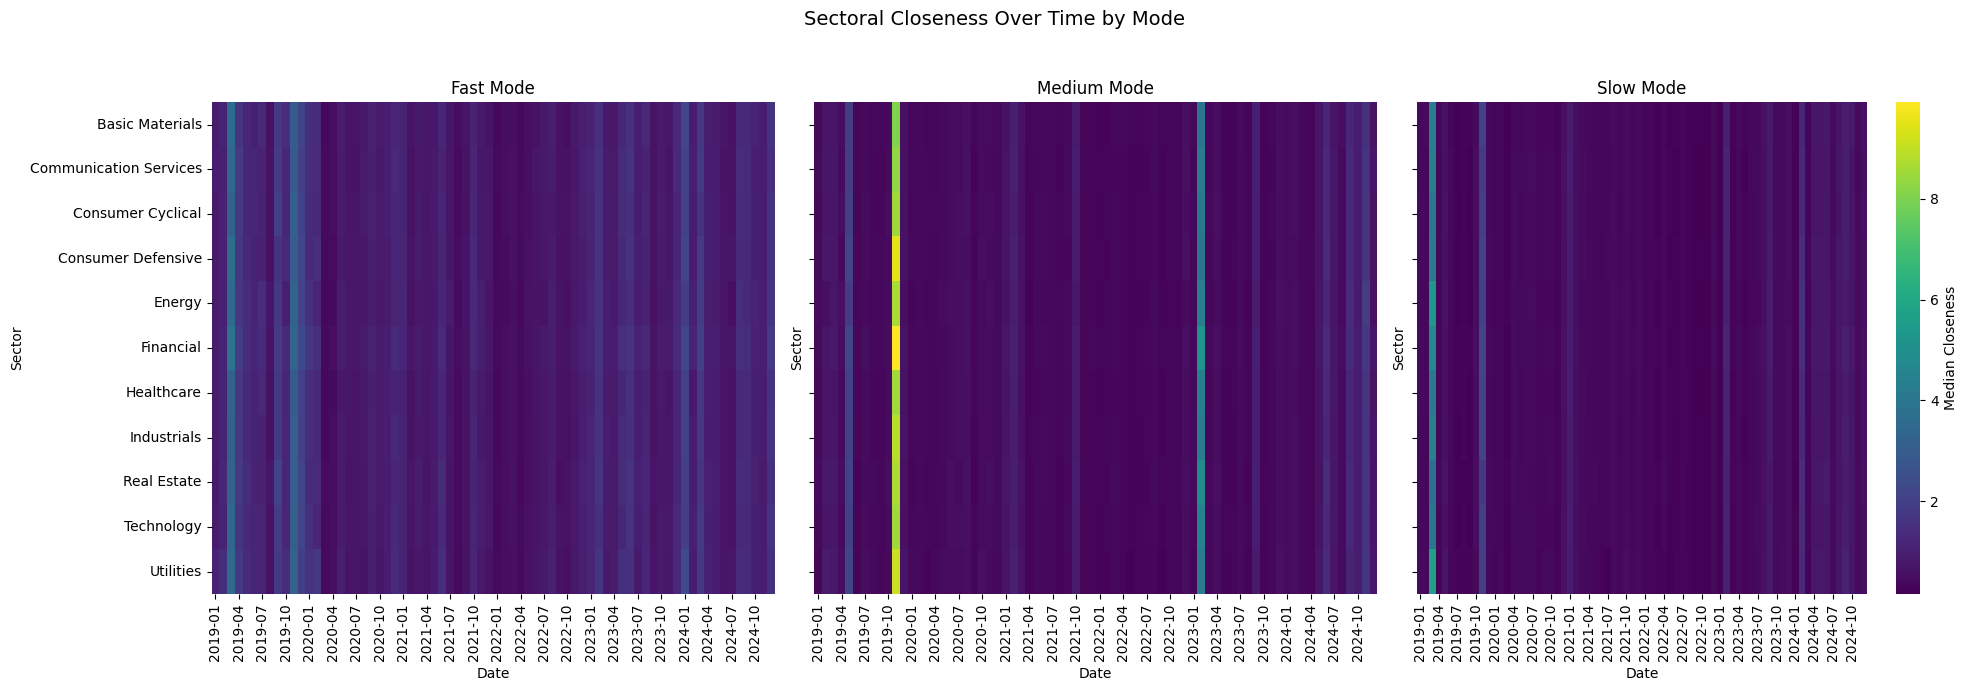

In [35]:
modes = ["Fast", "Medium", "Slow"]

# Calcular df_med por modo
df_med = (
    df.groupby(["year_month_dt", "Sector", "speed"], as_index=False)
      .agg({"closeness": "median"})
)

# Criar pivots por modo
pivots = {
    mode: df_med[df_med["speed"] == mode].pivot(
        index="Sector",
        columns="year_month_dt",
        values="closeness"
    )
    for mode in modes
}

# Escala comum de cores
vmin = min(p.min().min() for p in pivots.values())
vmax = max(p.max().max() for p in pivots.values())

fig, axes = plt.subplots(
    1, 3,
    figsize=(20, 7),
    sharey=True
)

for ax, mode in zip(axes, modes):
    sns.heatmap(
        pivots[mode],
        ax=ax,
        cmap="viridis",
        vmin=vmin,
        vmax=vmax,
        cbar=(mode == "Slow"),  # barra só no último
        cbar_kws={"label": "Median Closeness"} if mode == "Slow" else None
    )

    # Format x-ticks
    xticks = ax.get_xticks()
    xticklabels = [
        pivots[mode].columns[int(tick)].strftime("%Y-%m")
        if int(tick) < len(pivots[mode].columns) else ""
        for tick in xticks
    ]
    ax.set_xticklabels(xticklabels, rotation=90)

    ax.set_title(f"{mode} Mode")
    ax.set_xlabel("Date")

axes[0].set_ylabel("Sector")

plt.suptitle("Sectoral Closeness Over Time by Mode", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

C:\Users\groque\AppData\Local\Temp\ipykernel_9352\3129960941.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["year_month_dt", "mcap_bin", "speed"], as_index=False)


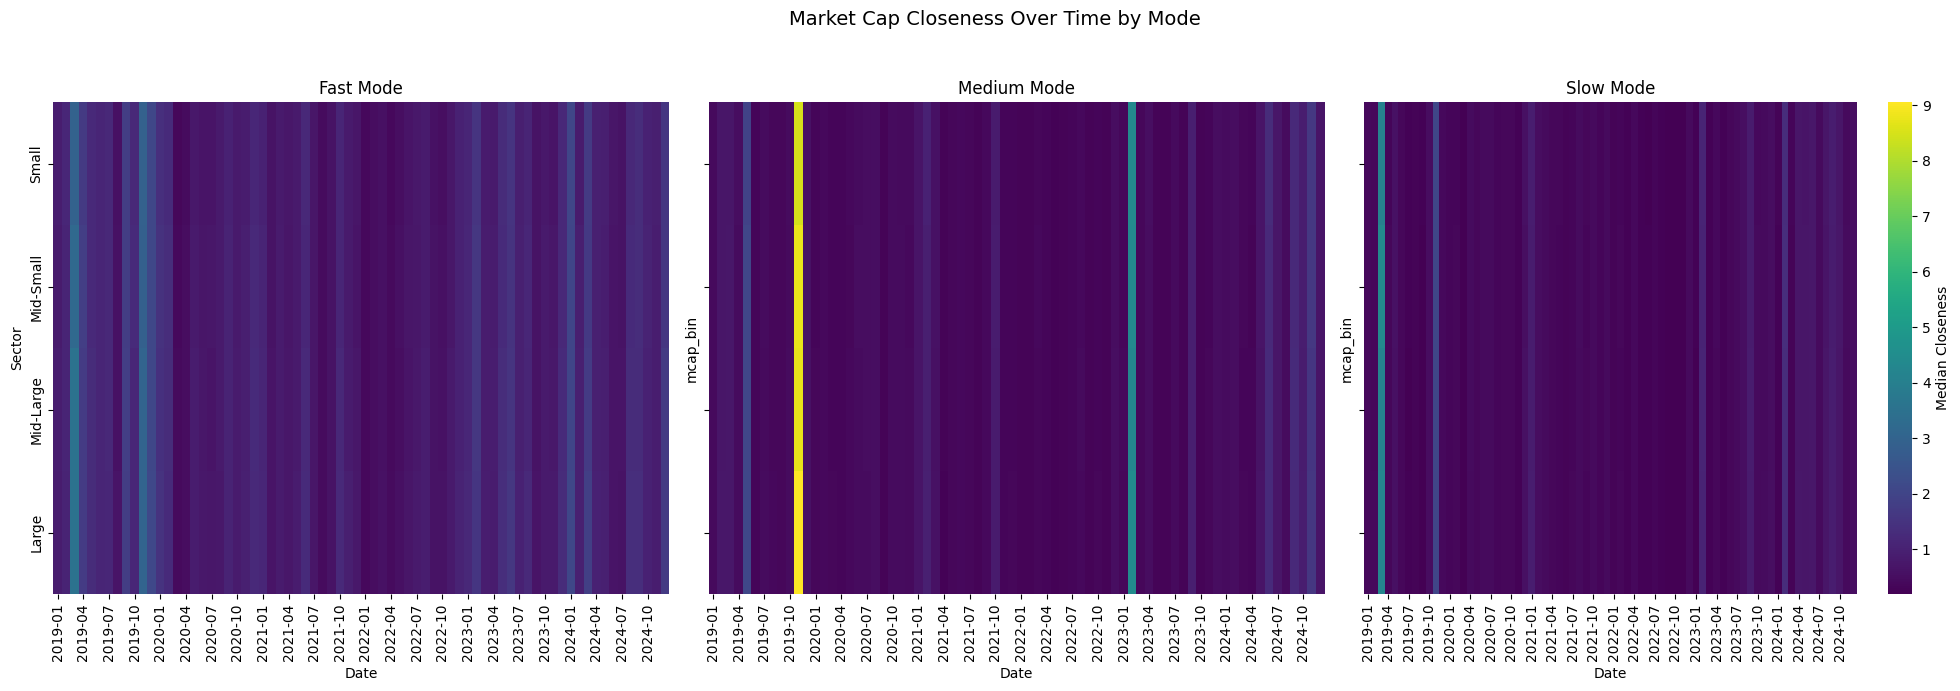

In [136]:
df["mcap_bin"] = (
    df.groupby("year_month_dt")["Market Cap"]
      .transform(lambda x: pd.qcut(
          x, q=4, labels=["Small", "Mid-Small", "Mid-Large", "Large"]
      ))
)

modes = ["Fast", "Medium", "Slow"]

# Calcular df_med por modo
df_med = (
    df.groupby(["year_month_dt", "mcap_bin", "speed"], as_index=False)
      .agg({"closeness": "median"})
)

# Criar pivots por modo
pivots = {
    mode: df_med[df_med["speed"] == mode].pivot(
        index="mcap_bin",
        columns="year_month_dt",
        values="closeness"
    )
    for mode in modes
}

# Escala comum de cores
vmin = min(p.min().min() for p in pivots.values())
vmax = max(p.max().max() for p in pivots.values())

fig, axes = plt.subplots(
    1, 3,
    figsize=(20, 7),
    sharey=True
)

for ax, mode in zip(axes, modes):
    sns.heatmap(
        pivots[mode],
        ax=ax,
        cmap="viridis",
        vmin=vmin,
        vmax=vmax,
        cbar=(mode == "Slow"),  # barra só no último
        cbar_kws={"label": "Median Closeness"} if mode == "Slow" else None
    )

    # Format x-ticks
    xticks = ax.get_xticks()
    xticklabels = [
        pivots[mode].columns[int(tick)].strftime("%Y-%m")
        if int(tick) < len(pivots[mode].columns) else ""
        for tick in xticks
    ]
    ax.set_xticklabels(xticklabels, rotation=90)

    ax.set_title(f"{mode} Mode")
    ax.set_xlabel("Date")

axes[0].set_ylabel("Sector")

plt.suptitle("Market Cap Closeness Over Time by Mode", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

Nenhum market cap se destaca pelo closeness.

## Análise 7 - Anual

In [138]:
df["year"] = df["year_month_dt"].dt.year

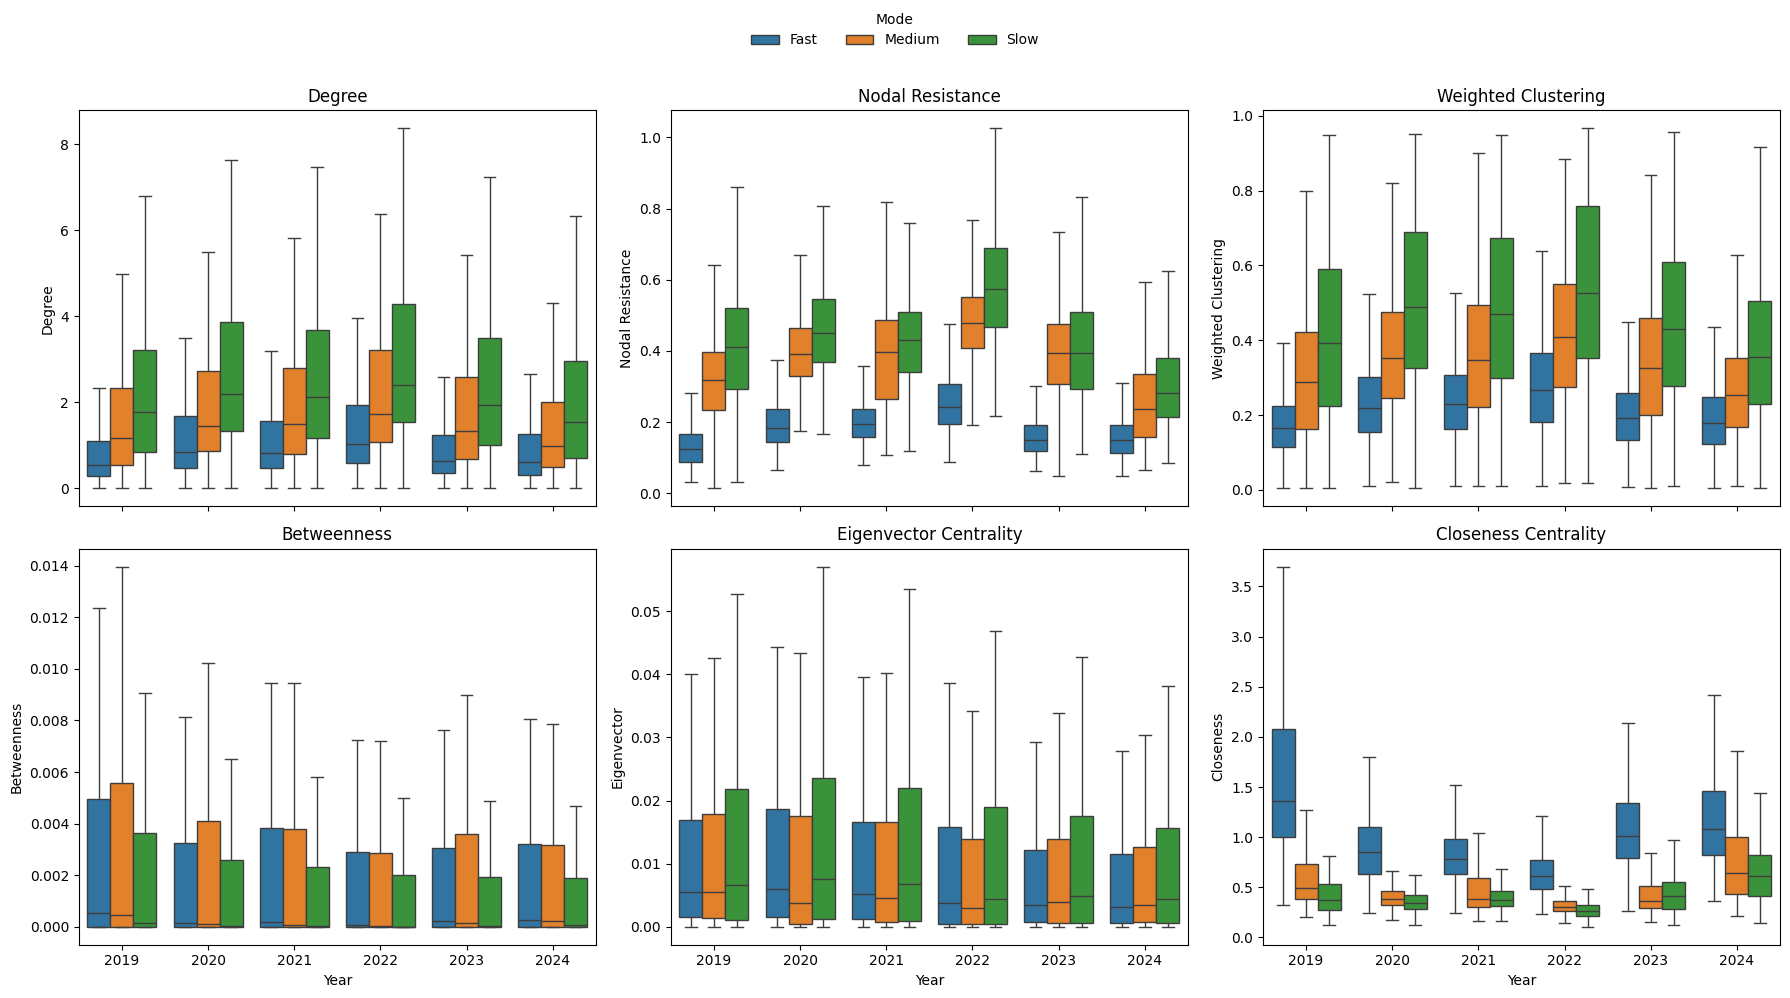

In [ ]:
metrics = [
    "degree",
    "nodal_resistance",
    "weighted_clustering",
    "betweenness",
    "eigenvector",
    "closeness"
]

titles = [
    "Degree",
    "Nodal Resistance",
    "Weighted Clustering",
    "Betweenness",
    "Eigenvector Centrality",
    "Closeness Centrality"
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharex=True)

axes = axes.flatten()

for ax, metric, title in zip(axes, metrics, titles):
    sns.boxplot(
        data=df,
        x="year",
        y=metric,
        hue="speed",
        showfliers=False,
        ax=ax
    )
    
    ax.set_title(title)
    ax.set_xlabel("Year")
    ax.set_ylabel(metric.replace("_", " ").title())

# remover legendas duplicadas
handles, labels = axes[0].get_legend_handles_labels()
for ax in axes:
    ax.get_legend().remove()

# legenda única
fig.legend(
    handles,
    labels,
    title="Mode",
    loc="upper center",
    ncol=3,
    frameon=False
)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

In [169]:
metrics = [
    "degree",
    "nodal_resistance",
    "weighted_clustering",
    "betweenness",
    "eigenvector",
    "closeness"
]

df.groupby("speed")[metrics].mean().T

speed,Fast,Medium,Slow
degree,1.524464,2.621299,3.582682
nodal_resistance,0.187041,0.366550,0.431723
weighted_clustering,0.223007,0.340783,0.457852
betweenness,0.009918,0.012220,0.012839
eigenvector,0.013808,0.014048,0.015409
closeness,1.035361,0.661615,0.501375


### Degree

Fast < Medium < Slow

Ativos no modo Slow têm, em média, mais conexões.

Indica maior sincronização ou correlação persistente entre ativos.

No modo Fast, as conexões são mais esparsas → relações mais transitórias.

🧠 Interpretação econômica:

O mercado em regime Slow apresenta maior interdependência estrutural.

### Nodal Resistance

Cresce fortemente de Fast para Slow

Menor resistência (Fast) → choques se dissipam mais facilmente.

Maior resistência (Slow) → estruturas mais rígidas, com propagação mais persistente.

🧠 Interpretação econômica:

Regimes lentos são menos adaptativos, favorecendo amplificação de choques.

### Weighted Clustering

Aumenta de forma consistente

Maior clustering no modo Slow indica formação de blocos/setores coesos.

No Fast, as relações são mais globais e menos triádicas.

🧠 Interpretação econômica:

Evidência de segmentação estrutural em regimes lentos.

### Betweenness

Aumenta levemente

Sugere maior presença de ativos intermediadores em Medium e Slow.

Mesmo aumento pequeno é relevante, pois betweenness tende a ser muito assimétrica.

🧠 Interpretação econômica:

Alguns ativos passam a atuar como canais críticos de transmissão.

### Eigenvector Centrality

Crescimento modesto, mas monotônico

Ativos conectados a outros ativos importantes tornam-se mais frequentes no Slow.

Indica hierarquização crescente da rede.

🧠 Interpretação econômica:

A influência estrutural se concentra em poucos nós dominantes.

### Closeness

Cai fortemente: Fast > Medium > Slow

No modo Fast, ativos estão topologicamente mais próximos.

No Slow, a rede é mais fragmentada ou alongada.

🧠 Interpretação econômica:

O acesso médio à informação se deteriora em regimes lentos.